# Forecasting retail demand under stockouts with `numpyro_forecast`

The [FreshRetailNet-50K](https://huggingface.co/datasets/Dingdong-Inc/FreshRetailNet-50K) dataset ([Yang et al., 2025](https://arxiv.org/abs/2505.16319)) contains $50{,}000$ daily store-product demand series from fresh retail operations: $90$ days per series with hourly sales, hourly stockout labels, promotion, discount, and calendar covariates. Its native stockout signal makes it a great public benchmark for a classic operational problem: observed sales are a *censored* version of demand, because you cannot sell what is not on the shelf.

A natural way to model this is a multiplicative availability factor: latent demand follows a state space model and the observed mean is demand times a saturating function of the day's stock availability. This notebook ports that design (from the [hierarchical forecasting posts](https://juanitorduz.github.io/numpyro_hierarchical_forecasting_1/) and related demand modeling work on promotions and availability) onto the `numpyro_forecast` API. There is a catch, though, and it is the heart of this example: **days whose stockout labels say the product was out of stock all day still record positive sales about $15\%$ of the time**. A pure multiplicative factor forces the mean to zero on those days and badly misfits them.

We proceed in three steps. First, an exploratory analysis of the full $50{,}000$-series dataset quantifies the contradiction and traces it to noisy stockout labels concentrated in hours that carry almost no demand, which motivates both a *sales-weighted* availability feature and a *learned floor* in the availability factor. Second, we fit a hierarchical state space model to the top $1{,}000$ series with SVI and a custom `optax` optimizer, wrapping the results in an ArviZ `DataTree`. Third, we evaluate the forecasts with CRPS and central-interval coverage on a simple train-test split against a seasonal-naive baseline.

## Prepare notebook

In [1]:
from typing import cast

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import optax
import polars as pl
import xarray as xr
from huggingface_hub import hf_hub_download
from jax import random
from jaxtyping import Float, Int
from numpyro import handlers
from numpyro.infer import Predictive
from numpyro.infer.reparam import LocScaleReparam

from numpyro_forecast import ForecastingModel, eval_coverage, eval_crps, to_datatree
from numpyro_forecast.features import periodic_repeat
from numpyro_forecast.functional import fit_svi
from numpyro_forecast.metrics import crps_empirical
from numpyro_forecast.typing import Array

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)

%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

## Read data

We download the training split (a single parquet file, cached locally by `huggingface_hub`) and scan it lazily with polars, so the full-dataset aggregations below stream instead of materializing all $4.5$ million rows.

In [2]:
parquet_path: str = hf_hub_download(
    repo_id="Dingdong-Inc/FreshRetailNet-50K",
    filename="data/train.parquet",
    repo_type="dataset",
)
data_lf = pl.scan_parquet(parquet_path)

data_lf.collect_schema()

Schema([('city_id', Int64),
        ('store_id', Int64),
        ('management_group_id', Int64),
        ('first_category_id', Int64),
        ('second_category_id', Int64),
        ('third_category_id', Int64),
        ('product_id', Int64),
        ('dt', String),
        ('sale_amount', Float64),
        ('hours_sale', List(Float64)),
        ('stock_hour6_22_cnt', Int32),
        ('hours_stock_status', List(Int64)),
        ('discount', Float64),
        ('holiday_flag', Int32),
        ('activity_flag', Int32),
        ('precpt', Float64),
        ('avg_temperature', Float64),
        ('avg_humidity', Float64),
        ('avg_wind_level', Float64)])

In [3]:
data_lf.select(
    pl.len().alias("rows"),
    pl.col("city_id").n_unique().alias("cities"),
    pl.col("store_id").n_unique().alias("stores"),
    pl.col("product_id").n_unique().alias("products"),
    pl.struct(["store_id", "product_id"]).n_unique().alias("series"),
    pl.col("dt").min().alias("start_date"),
    pl.col("dt").max().alias("end_date"),
).collect(engine="streaming")

rows,cities,stores,products,series,start_date,end_date
u32,u32,u32,u32,u32,str,str
4500000,18,898,865,50000,"""2024-03-28""","""2024-06-25"""


Every one of the $50{,}000$ store-product series covers the same $90$ days. Three columns drive this notebook:

- `sale_amount` is the daily sales target, and `hours_sale` is its hourly decomposition (it sums exactly to `sale_amount`).
- `hours_stock_status` is a $24$-vector of hourly stockout indicators ($1$ means out of stock in that hour).
- `stock_hour6_22_cnt` counts stockout hours within the $6{:}00$ to $22{:}00$ daytime window, so its maximum is $16$.

The next cell verifies these conventions directly instead of trusting the documentation.

In [4]:
data_lf.select(
    (pl.col("hours_sale").list.sum() - pl.col("sale_amount")).abs().max().alias("max_abs_diff"),
    pl.col("hours_stock_status").list.len().max().alias("hours_per_day"),
    pl.col("stock_hour6_22_cnt").max().alias("max_daytime_stockout_hours"),
).collect(engine="streaming")

max_abs_diff,hours_per_day,max_daytime_stockout_hours
f64,u32,i32
1.4211e-14,24,16


## Exploratory data analysis

### How prevalent are stockouts?

[Text(0.5, 0, 'stockout hours per day'),
 Text(0, 0.5, 'share of days'),
 Text(0.5, 1.0, 'Distribution of daily stockout hours')]

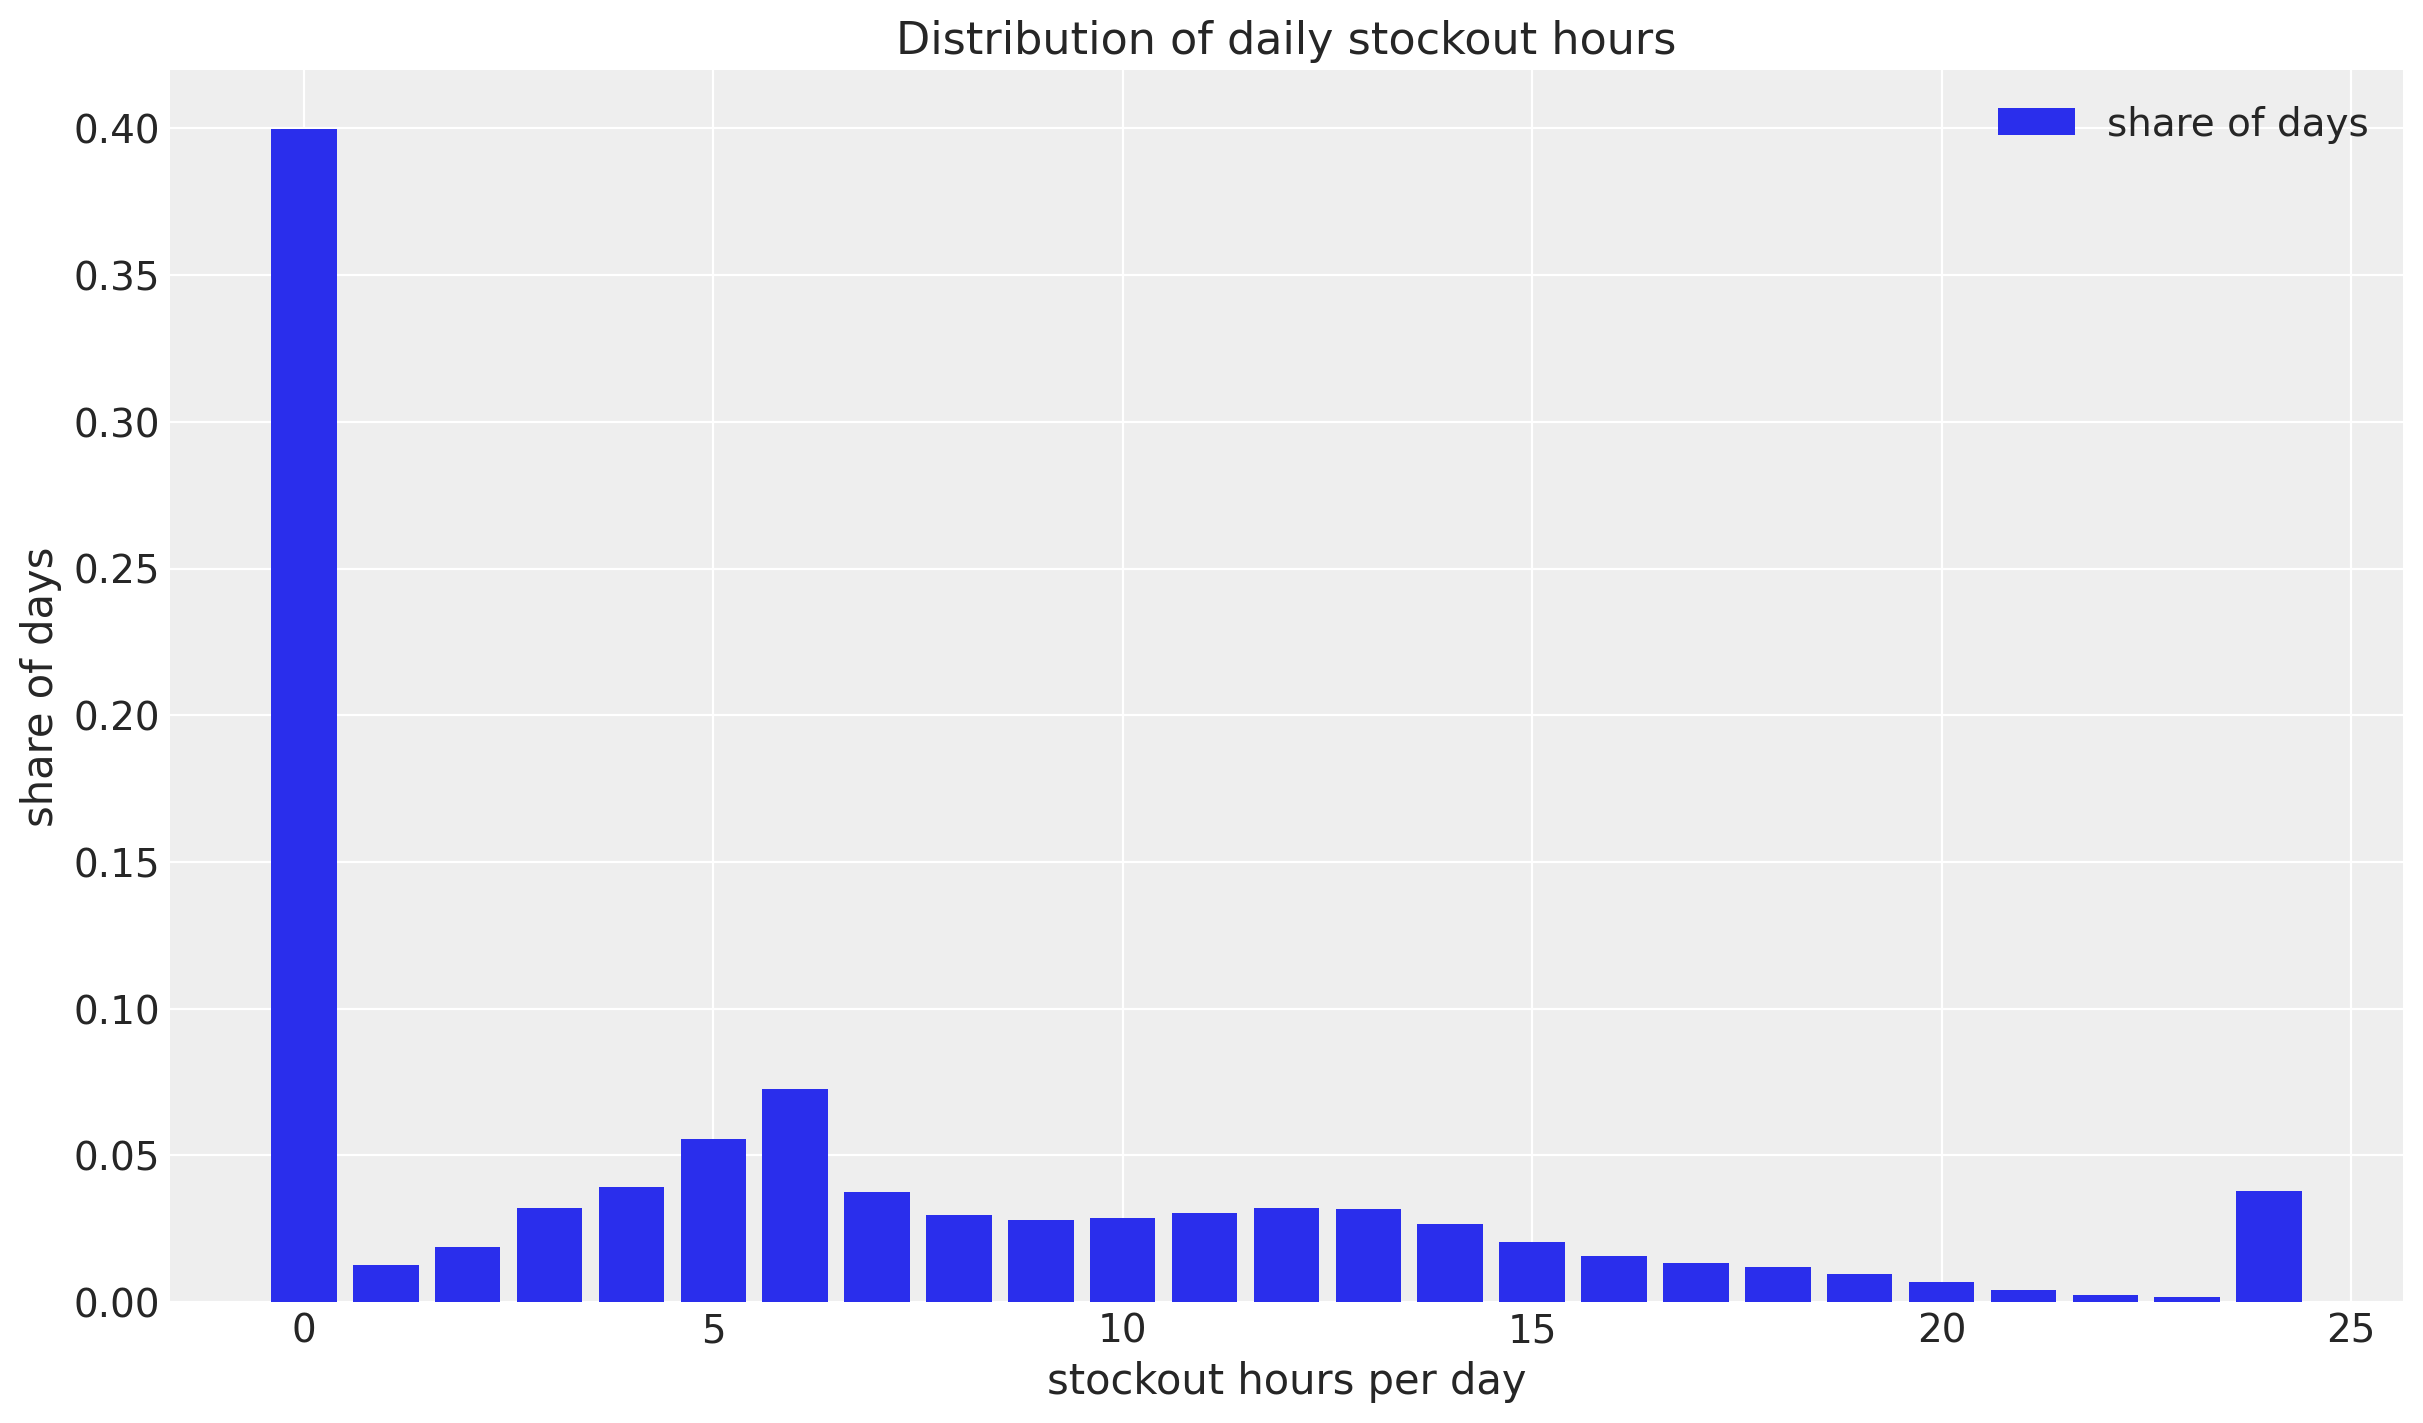

In [5]:
stockout_hours_df = (
    data_lf.select(pl.col("hours_stock_status").list.sum().alias("stockout_hours"))
    .group_by("stockout_hours")
    .len()
    .sort("stockout_hours")
    .with_columns((pl.col("len") / pl.col("len").sum()).alias("share_of_days"))
    .collect(engine="streaming")
)

fig, ax = plt.subplots()
ax.bar(
    stockout_hours_df["stockout_hours"],
    stockout_hours_df["share_of_days"],
    color="C0",
    label="share of days",
)
ax.legend(loc="upper right")
ax.set(
    xlabel="stockout hours per day",
    ylabel="share of days",
    title="Distribution of daily stockout hours",
)

The distribution is strongly bimodal: $40\%$ of the days have no stockout at all, most of the rest lose a handful of hours, and a visible spike of about $3.8\%$ of the days is flagged out of stock for all $24$ hours.

### The contradiction: sales on fully out-of-stock days

If the labels were exact, a day flagged out of stock for every hour could not sell anything. Let us check that under both stockout definitions (all $24$ hours flagged, and all $16$ daytime hours flagged).

In [6]:
max_daytime_hours = 16

data_lf.with_columns(
    (pl.col("hours_stock_status").list.sum() == 24).alias("oos_all_day"),
    (pl.col("stock_hour6_22_cnt") == max_daytime_hours).alias("oos_daytime"),
    pl.col("sale_amount").mean().over("store_id", "product_id").alias("series_mean"),
).select(
    pl.col("oos_all_day").mean().alias("share_days_oos_all_day"),
    pl.col("oos_daytime").mean().alias("share_days_oos_daytime"),
    (pl.col("sale_amount") > 0).filter(pl.col("oos_all_day")).mean().alias("p_sales_oos_all_day"),
    (pl.col("sale_amount") > 0).filter(pl.col("oos_daytime")).mean().alias("p_sales_oos_daytime"),
    (pl.col("sale_amount") / pl.col("series_mean"))
    .filter(pl.col("oos_all_day") & (pl.col("sale_amount") > 0))
    .mean()
    .alias("relative_sales_when_positive"),
).collect(engine="streaming")

share_days_oos_all_day,share_days_oos_daytime,p_sales_oos_all_day,p_sales_oos_daytime,relative_sales_when_positive
f64,f64,f64,f64,f64
0.037937,0.040398,0.147589,0.185631,0.248096


About $15\%$ of the all-day stockout days (and $19\%$ of the daytime ones) still record positive sales, and when they do the amount is not negligible: about a quarter of the series' average daily sales. Plausible mechanisms are stockout labels reconstructed from inventory snapshots, a sell-out followed by a restock within the same hour, or back-room stock that never registered on the shelf system. Whatever the cause, the labels are noisy, and a model that pins the mean at zero whenever recorded availability is zero is misspecified.

### When do sales and stockouts happen within the day?

The hourly decomposition tells us how much each flagged hour actually matters for daily demand.

[Text(0.5, 0, 'hour of day'),
 Text(0, 0.5, 'share of daily sales'),
 Text(0.5, 1.0, 'Hourly sales profile vs hourly stockout rate')]

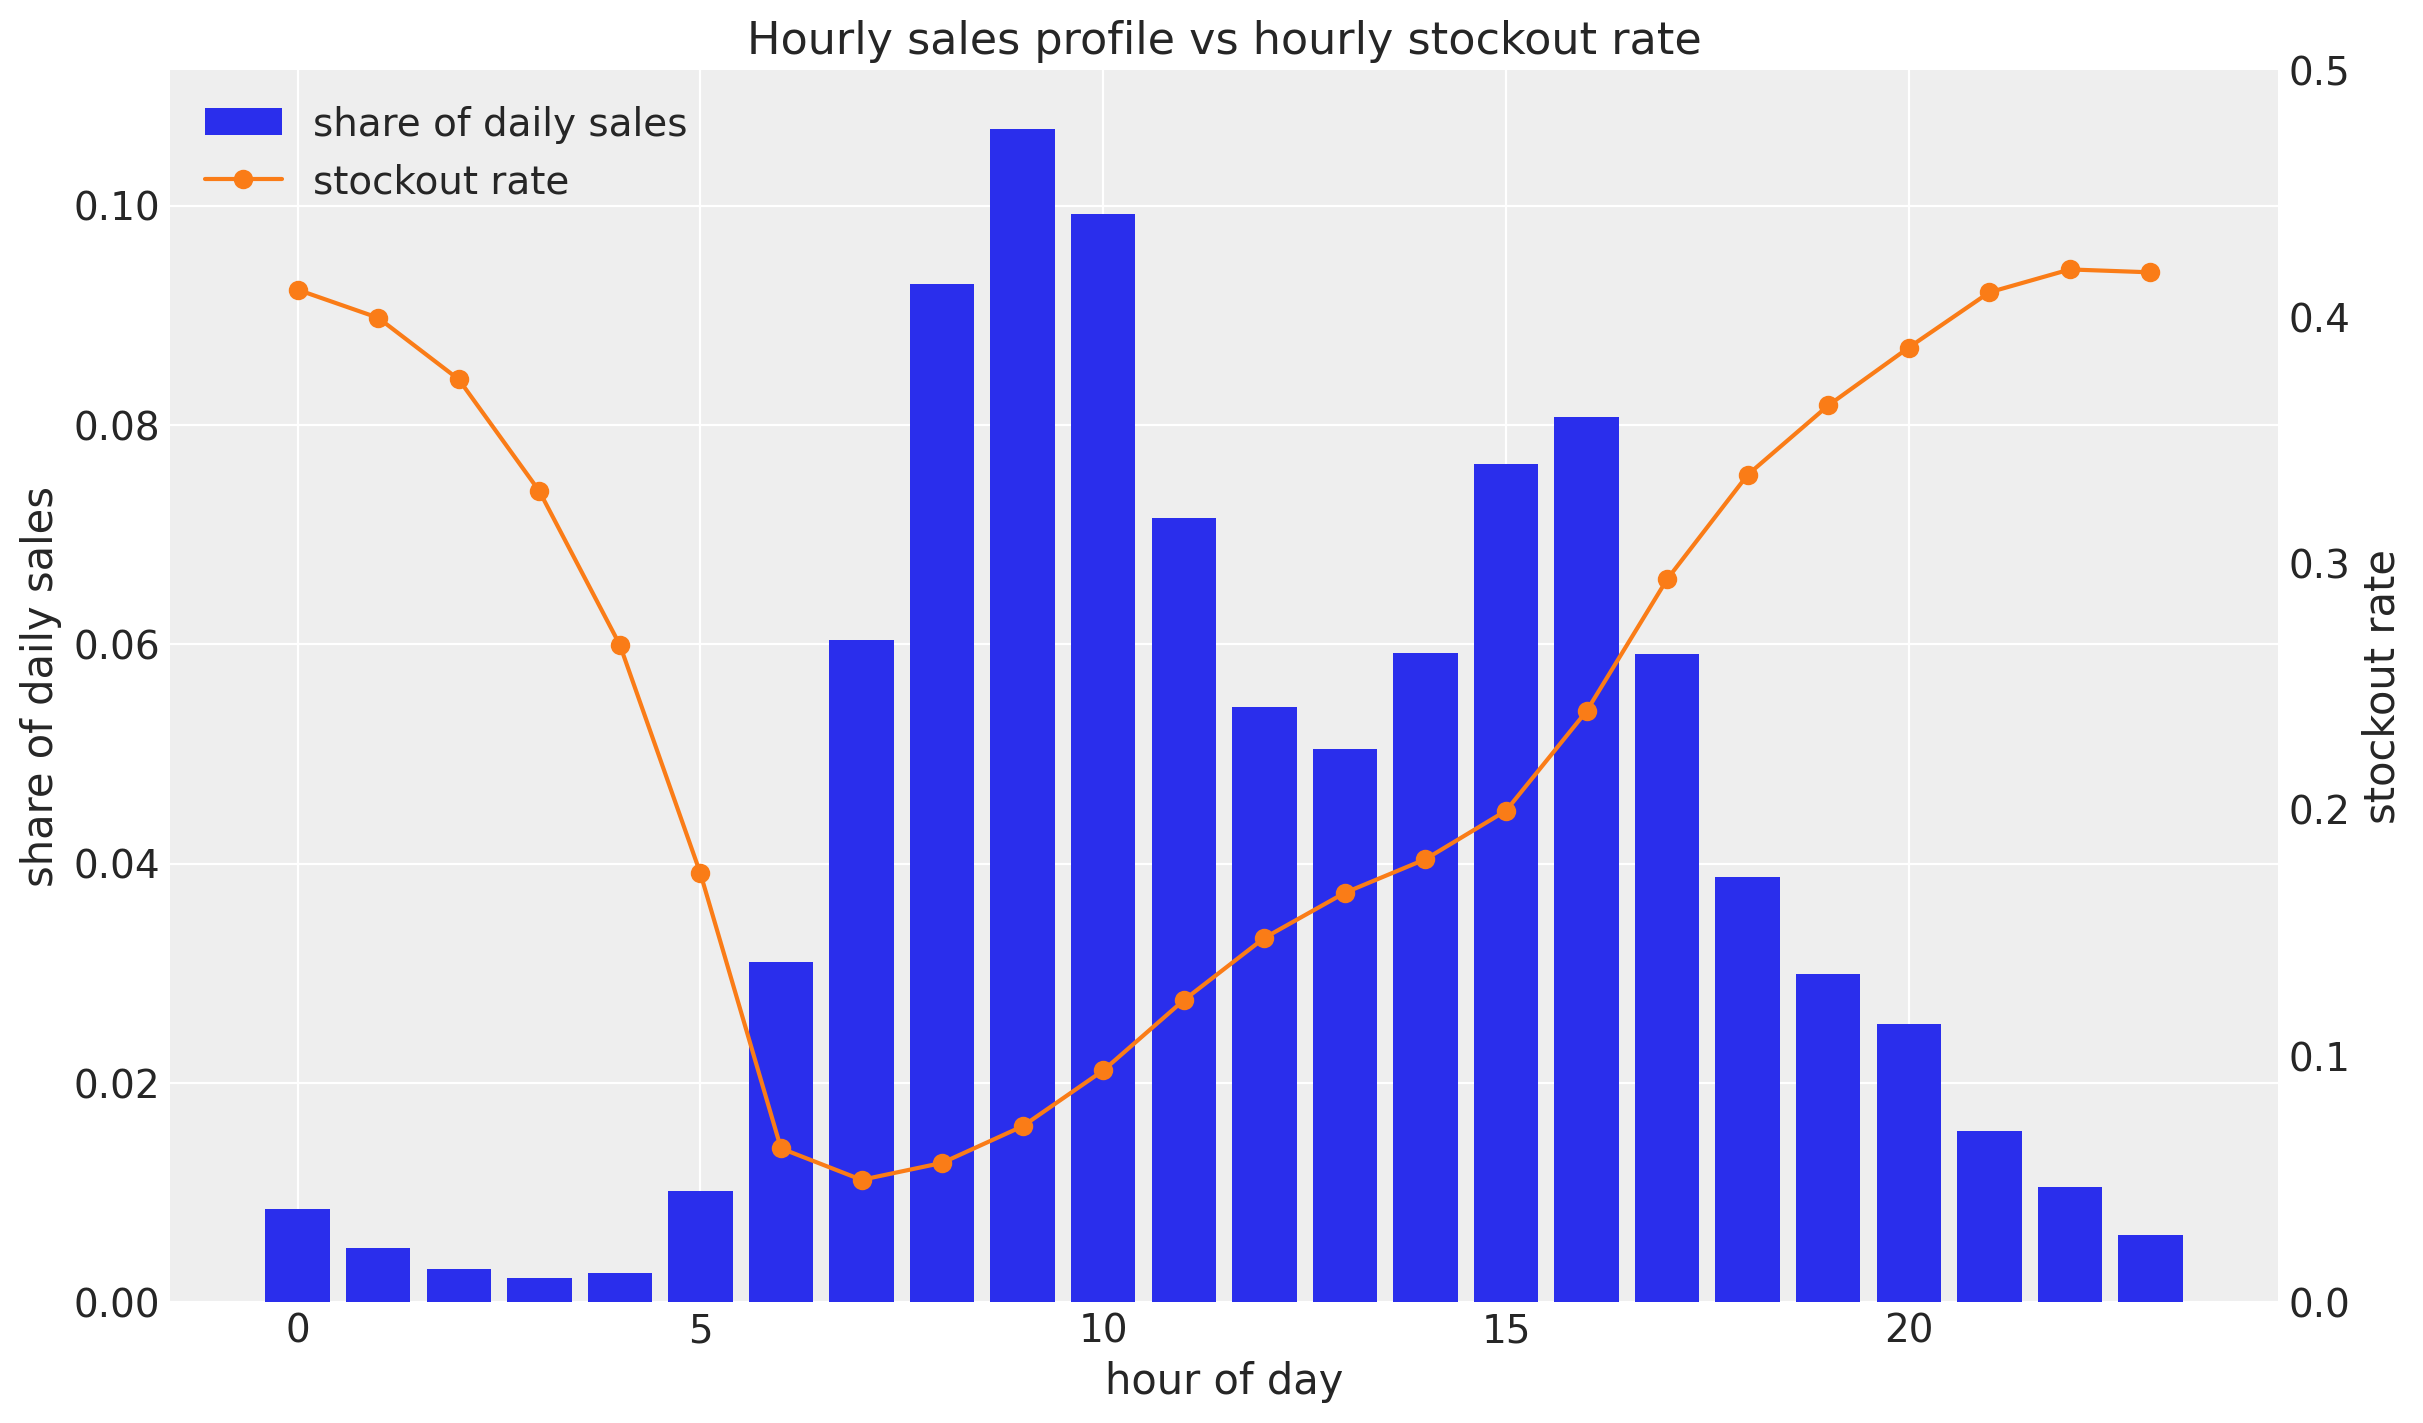

In [7]:
hourly_row = (
    data_lf.select(
        *[pl.col("hours_sale").list.get(h).sum().alias(f"sales_{h}") for h in range(24)],
        *[pl.col("hours_stock_status").list.get(h).mean().alias(f"oos_{h}") for h in range(24)],
    )
    .collect(engine="streaming")
    .row(0)
)
sales_by_hour = np.asarray(hourly_row[:24], dtype=np.float64)
stockout_rate_by_hour = np.asarray(hourly_row[24:], dtype=np.float64)
hourly_weights = sales_by_hour / sales_by_hour.sum()

fig, ax = plt.subplots()
ax.bar(np.arange(24), hourly_weights, color="C0", label="share of daily sales")
ax_twin = ax.twinx()
ax_twin.plot(np.arange(24), stockout_rate_by_hour, color="C1", marker="o", label="stockout rate")
ax_twin.grid(False)
ax_twin.set(ylabel="stockout rate", ylim=(0, 0.5))
handles, labels_ = ax.get_legend_handles_labels()
handles_twin, labels_twin = ax_twin.get_legend_handles_labels()
ax.legend(handles + handles_twin, labels_ + labels_twin, loc="upper left")
ax.set(
    xlabel="hour of day",
    ylabel="share of daily sales",
    title="Hourly sales profile vs hourly stockout rate",
)

The two curves are almost mirror images: sales concentrate between $7{:}00$ and $20{:}00$ ($96\%$ of all sales fall in the $6{:}00$ to $22{:}00$ window), while the stockout rate peaks overnight at around $40\%$, exactly when nobody is buying. A raw $24$-hour stockout count therefore heavily over-penalizes availability. We can also measure the label noise directly: how much of the total sales volume is recorded in hours that are flagged out of stock?

In [8]:
data_lf.select(
    (
        pl.sum_horizontal(
            [
                (pl.col("hours_sale").list.get(h) * pl.col("hours_stock_status").list.get(h))
                for h in range(24)
            ]
        ).sum()
        / pl.col("hours_sale").list.sum().sum()
    ).alias("share_of_sales_in_flagged_stockout_hours")
).collect(engine="streaming")

share_of_sales_in_flagged_stockout_hours
f64
0.025131


$2.5\%$ of *all* sales happen in hours the labels declare out of stock. This is direct, hour-level evidence that the stockout signal has noise that no availability feature can remove, and it is why the model below learns a floor instead of trusting availability zero to mean demand zero.

### A sales-weighted availability feature

Instead of counting stockout hours uniformly, we weight each hour by its share of global sales, so that losing a night hour costs almost nothing and losing the morning peak costs a lot:

$$a_{t,s} = \sum_{h=0}^{23} w_h \left(1 - \text{stockout}_{t,s,h}\right), \qquad w_h = \frac{\text{total sales in hour } h}{\text{total sales}}.$$

In [9]:
availability_expr = pl.sum_horizontal(
    [(1 - pl.col("hours_stock_status").list.get(h)) * float(hourly_weights[h]) for h in range(24)]
).alias("availability")


def zero_availability_summary(zero_flag: pl.Expr, definition: str) -> pl.LazyFrame:
    """Summarize the zero-availability days implied by one stockout definition."""
    return data_lf.with_columns(zero_flag.alias("zero_availability")).select(
        pl.lit(definition).alias("definition"),
        pl.col("zero_availability").mean().alias("share_days_zero_availability"),
        (pl.col("sale_amount") > 0)
        .filter(pl.col("zero_availability"))
        .mean()
        .alias("p_positive_sales_given_zero"),
    )


pl.concat(
    [
        zero_availability_summary(
            pl.col("stock_hour6_22_cnt") == max_daytime_hours, "daytime hours all flagged"
        ),
        zero_availability_summary(
            pl.col("hours_stock_status").list.sum() == 24, "all 24 hours flagged"
        ),
        zero_availability_summary(availability_expr == 0, "sales-weighted availability = 0"),
    ]
).collect(engine="streaming")

definition,share_days_zero_availability,p_positive_sales_given_zero
str,f64,f64
"""daytime hours all flagged""",0.040398,0.185631
"""all 24 hours flagged""",0.037937,0.147589
"""sales-weighted availability = …",0.037937,0.147589


The weighted feature helps in two ways. Days that are only stocked overnight no longer count as available (they earn a tiny positive $a_{t,s}$ instead of the daytime definition's hard zero), and the contradiction rate at exact zero drops from $19\%$ (daytime definition) to $15\%$. That remaining $15\%$ is irreducible label noise, and the model handles it with a learned floor rather than a data transformation.

### The empirical demand-availability curve

How do sales respond to partial availability? We scale each series by its own mean (so different volumes are comparable) and bin the scaled sales by weighted availability.

empirical floor at zero availability: 0.037


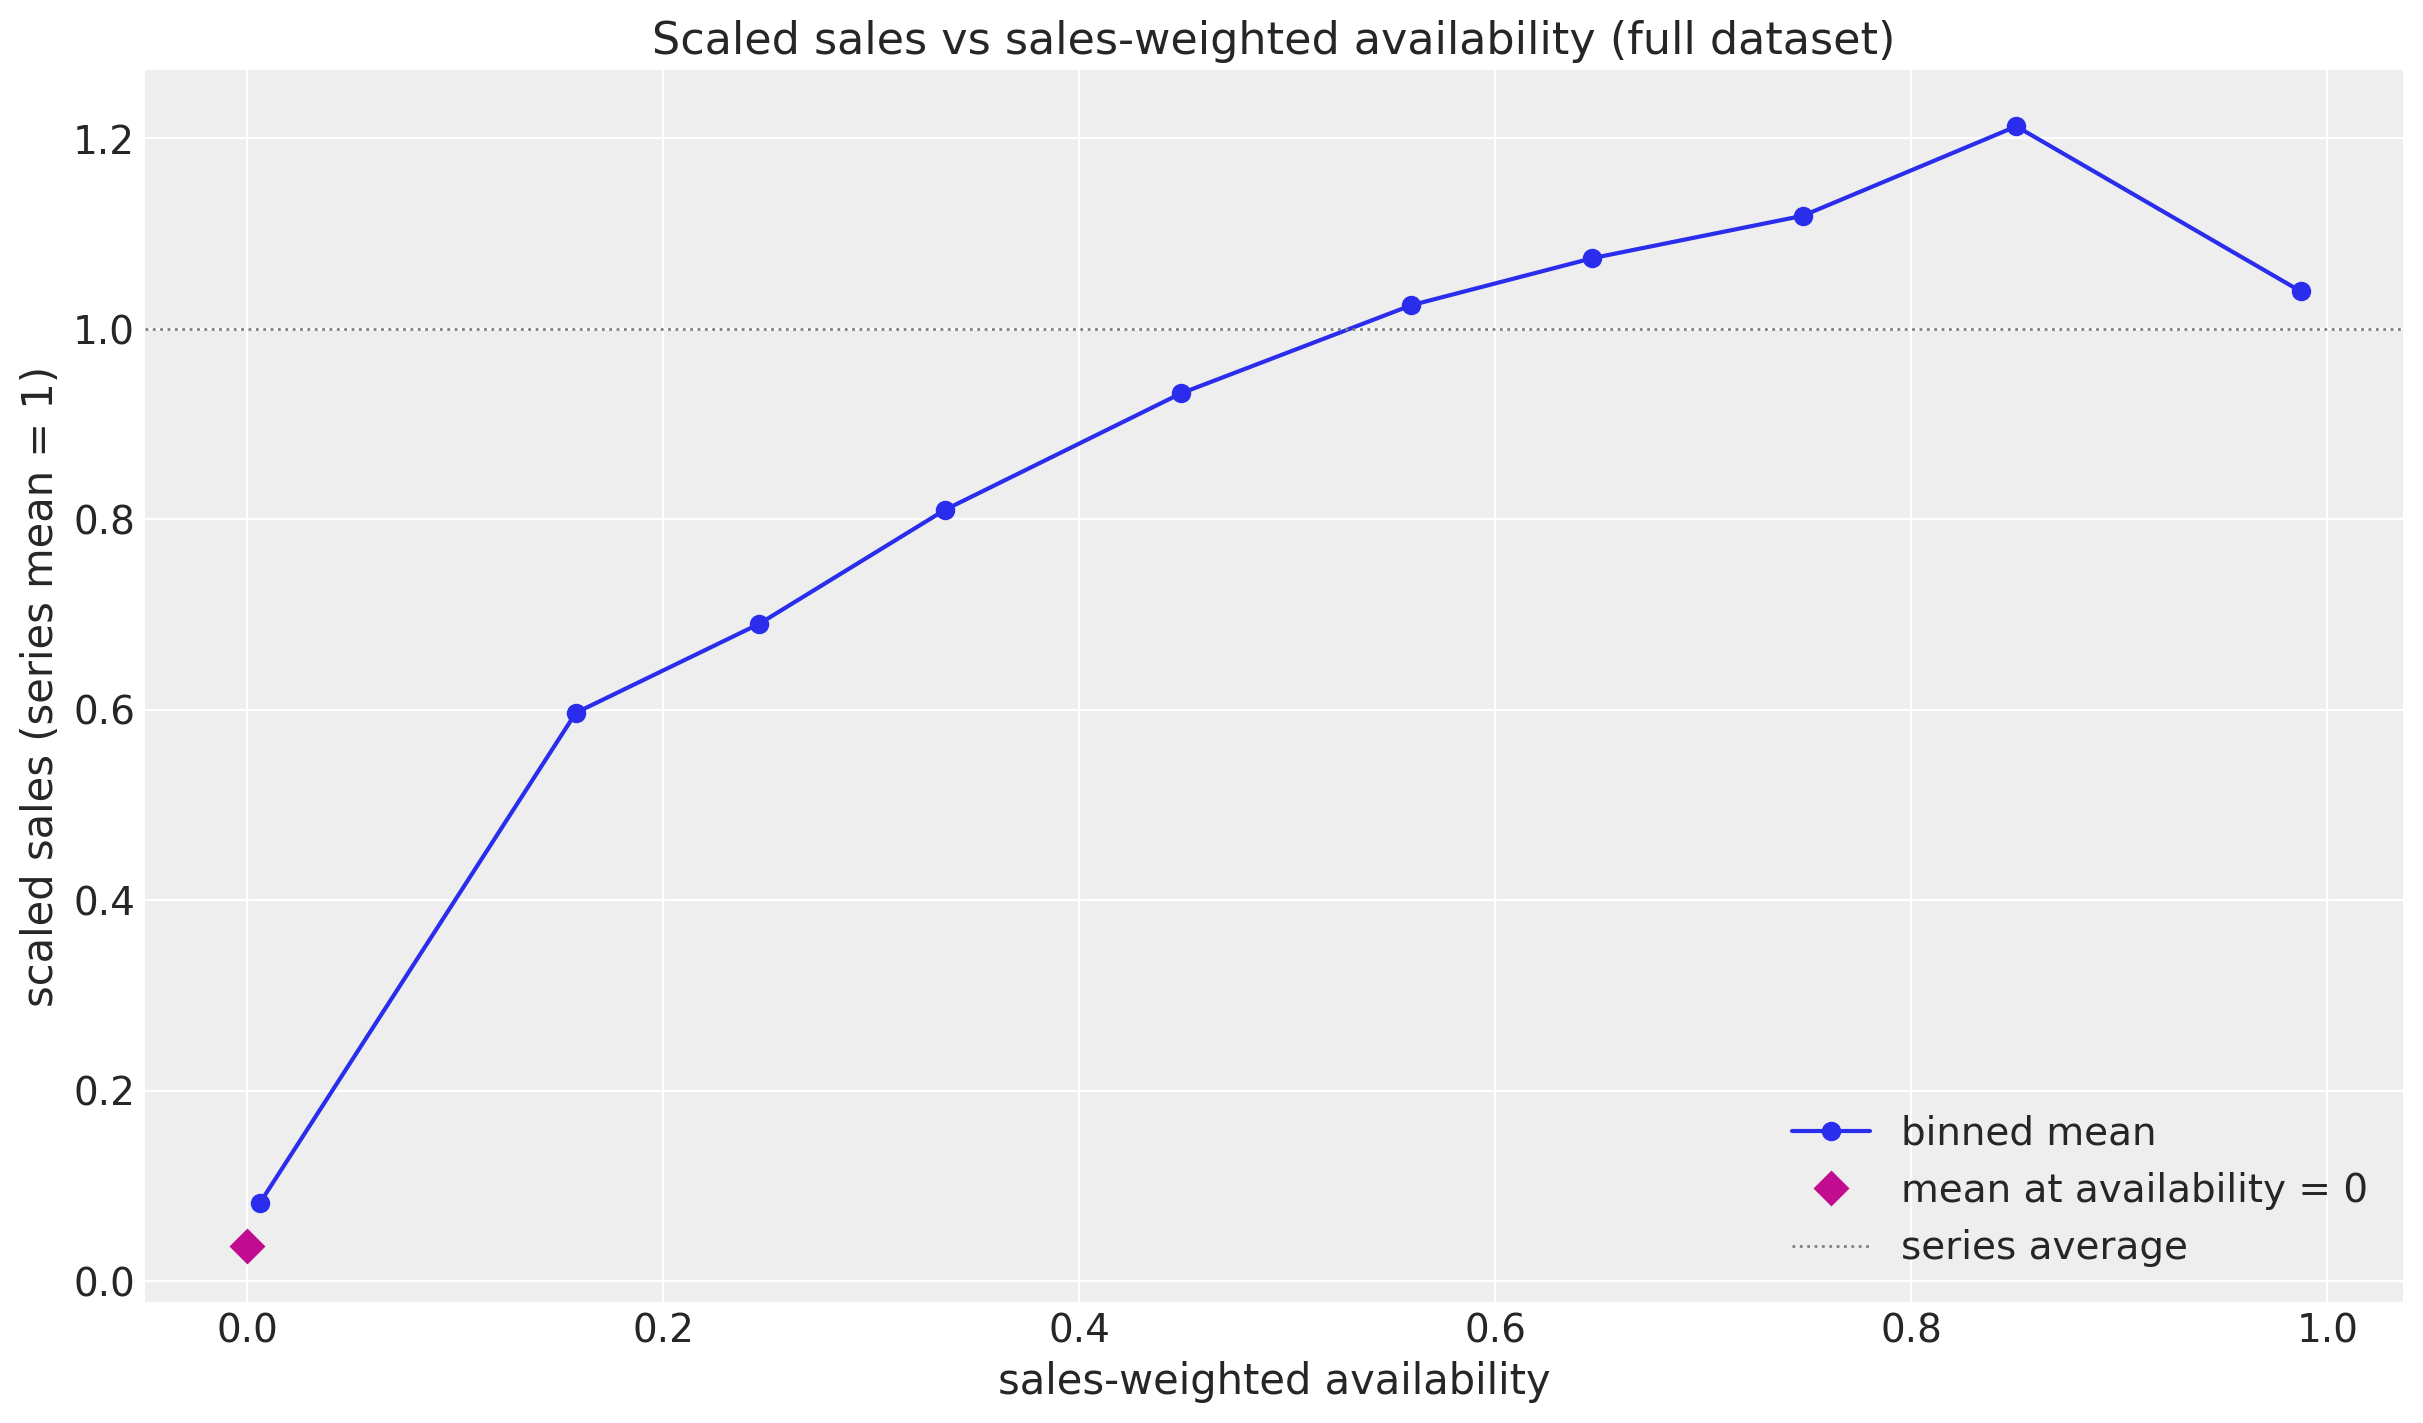

In [10]:
factor_curve_df = (
    data_lf.with_columns(
        availability_expr,
        pl.col("sale_amount").mean().over("store_id", "product_id").alias("series_mean"),
    )
    .with_columns((pl.col("sale_amount") / pl.col("series_mean")).alias("scaled_sales"))
    .with_columns((pl.col("availability") * 10).floor().clip(0, 9).alias("availability_bin"))
    .group_by("availability_bin")
    .agg(
        pl.col("availability").mean().alias("mean_availability"),
        pl.col("scaled_sales").mean().alias("mean_scaled_sales"),
        pl.len().alias("days"),
    )
    .sort("availability_bin")
    .collect(engine="streaming")
)

empirical_floor_df = (
    data_lf.with_columns(
        availability_expr,
        pl.col("sale_amount").mean().over("store_id", "product_id").alias("series_mean"),
    )
    .filter(pl.col("availability") == 0)
    .select(
        (pl.col("sale_amount") / pl.col("series_mean")).mean().alias("mean_scaled_sales"),
        pl.len().alias("days"),
    )
    .collect(engine="streaming")
)
empirical_floor = float(empirical_floor_df["mean_scaled_sales"][0])

fig, ax = plt.subplots()
ax.plot(
    factor_curve_df["mean_availability"],
    factor_curve_df["mean_scaled_sales"],
    "o-",
    color="C0",
    label="binned mean",
)
ax.plot(0.0, empirical_floor, "D", color="C3", markersize=8, label="mean at availability = 0")
ax.axhline(1.0, color="gray", linestyle=":", linewidth=1, label="series average")
ax.legend(loc="lower right")
ax.set(
    xlabel="sales-weighted availability",
    ylabel="scaled sales (series mean = 1)",
    title="Scaled sales vs sales-weighted availability (full dataset)",
)
print(f"empirical floor at zero availability: {empirical_floor:.3f}")

The curve is saturating, exactly the shape a multiplicative factor should have: steep gains at low availability, flattening out near full availability. Two details matter for the model. First, the value at zero availability is positive (about $0.04$), which is the empirical floor the factor must reproduce. Second, the bins just below full availability sit slightly *above* the fully-available bin. That is endogeneity, not magic: stockouts happen disproportionately on high-demand days (a sell-out is itself evidence of demand), so a naive read of this curve overstates what availability alone does. The model mitigates this by attributing day-to-day variation to the trend, weekly seasonality, and promotion covariates jointly with the factor.

### Promotion and calendar covariates

We encode the discount as `discount_magnitude = 1 - discount`, so zero means no discount and larger values mean deeper discounts (a positive coefficient then reads "more discount, more sales").

In [11]:
data_lf.with_columns(
    pl.col("sale_amount").mean().over("store_id", "product_id").alias("series_mean"),
    (1 - pl.col("discount")).alias("discount_magnitude"),
).with_columns((pl.col("sale_amount") / pl.col("series_mean")).alias("scaled_sales")).select(
    pl.col("discount_magnitude").mean().alias("mean_discount_magnitude"),
    (pl.col("discount_magnitude") > 0).mean().alias("share_days_discounted"),
    pl.col("activity_flag").mean().alias("share_days_activity"),
    pl.col("holiday_flag").mean().alias("share_days_holiday"),
    pl.col("scaled_sales").filter(pl.col("activity_flag") == 1).mean().alias("scaled_activity"),
    pl.col("scaled_sales").filter(pl.col("activity_flag") == 0).mean().alias("scaled_no_activity"),
    pl.col("scaled_sales").filter(pl.col("holiday_flag") == 1).mean().alias("scaled_holiday"),
    pl.col("scaled_sales").filter(pl.col("holiday_flag") == 0).mean().alias("scaled_no_holiday"),
).collect(engine="streaming")

mean_discount_magnitude,share_days_discounted,share_days_activity,share_days_holiday,scaled_activity,scaled_no_activity,scaled_holiday,scaled_no_holiday
f64,f64,f64,f64,f64,f64,f64,f64
0.088859,0.515299,0.378421,0.344444,1.113655,0.930806,1.147654,0.922419


Discounts are common (about half of all days, with a mean magnitude near $9\%$), and both promotion activity and holidays lift scaled sales by roughly $20\%$ on average. All three are worth including as regression covariates, with effects pooled hierarchically by store.

## Build the modeling panel

We model the top $1{,}000$ series by total sales. The last $14$ days are held out as a test set; the model trains on the first $76$ days and receives the *actual* covariates (availability, discount, promotion, holiday) over the forecast window, which is the standard retrospective evaluation setup. Each series is scaled by its training-window mean so a single set of priors works across products with very different volumes.

In [12]:
n_series_panel = 1_000
t_train = 76
horizon = 14

top_series_df = (
    data_lf.group_by("store_id", "product_id")
    .agg(pl.col("sale_amount").sum().alias("total_sales"))
    .sort("total_sales", descending=True)
    .head(n_series_panel)
    .collect(engine="streaming")
)

panel_df = (
    data_lf.join(
        top_series_df.lazy().select("store_id", "product_id"), on=["store_id", "product_id"]
    )
    .with_columns(
        pl.col("dt").cast(pl.Date),
        pl.concat_str(["store_id", "product_id"], separator="::").alias("unique_id"),
        availability_expr,
        (1 - pl.col("discount")).alias("discount_magnitude"),
    )
    .select(
        "dt",
        "unique_id",
        "store_id",
        "sale_amount",
        "availability",
        "discount_magnitude",
        pl.col("activity_flag").cast(pl.Float64),
        pl.col("holiday_flag").cast(pl.Float64),
    )
    .collect(engine="streaming")
    .sort("unique_id", "dt")
)

series_ids: list[str] = panel_df["unique_id"].unique().sort().to_list()
n_series = len(series_ids)
dates_series = panel_df["dt"].unique().sort()
dates = dates_series.to_numpy()

panel_df.head()

dt,unique_id,store_id,sale_amount,availability,discount_magnitude,activity_flag,holiday_flag
date,str,i64,f64,f64,f64,f64,f64
2024-03-28,"""0::117""",0,0.3,0.0,0.0,0.0,0.0
2024-03-29,"""0::117""",0,5.0,0.968539,0.0,0.0,0.0
2024-03-30,"""0::117""",0,6.6,1.0,0.0,0.0,1.0
2024-03-31,"""0::117""",0,8.0,1.0,0.0,0.0,1.0
2024-04-01,"""0::117""",0,0.5,0.122896,0.0,0.0,0.0


In [13]:
def make_pivot(value: str) -> Float[np.ndarray, " duration n_series"]:
    """Build the dense (date x series) matrix of one panel column.

    Columns follow ``series_ids`` order so every pivot shares the same series axis.
    """
    pivot_df = panel_df.pivot(index="dt", on="unique_id", values=value).sort("dt")
    matrix = pivot_df.select(series_ids).to_numpy().astype(np.float64)
    if matrix.shape != (len(dates), n_series) or np.isnan(matrix).any():
        msg = f"Unexpected pivot for {value!r}: shape {matrix.shape}"
        raise ValueError(msg)
    return matrix


y_full = make_pivot("sale_amount")
availability_full = make_pivot("availability")
features_full = np.stack(
    [make_pivot("discount_magnitude"), make_pivot("activity_flag"), make_pivot("holiday_flag")]
)
covariate_names = ["discount_magnitude", "activity_flag", "holiday_flag"]
n_covariates = len(covariate_names)

store_ids: list[int] = sorted(panel_df["store_id"].unique().to_list())
store_index = {store: idx for idx, store in enumerate(store_ids)}
series_store_df = panel_df.select("unique_id", "store_id").unique().sort("unique_id")
series_to_store = jnp.asarray(
    [store_index[store] for store in series_store_df["store_id"].to_list()], dtype=jnp.int32
)
n_stores = len(store_ids)

scale = y_full[:t_train].mean(axis=0)
y_scaled = y_full / scale[None, :]
y_train = jnp.asarray(y_scaled[:t_train], dtype=jnp.float32)
y_train_original = jnp.asarray(y_full[:t_train], dtype=jnp.float32)
y_test_original = jnp.asarray(y_full[t_train:], dtype=jnp.float32)
scale_jax = jnp.asarray(scale, dtype=jnp.float32)

print(f"panel: {n_series} series, {n_stores} stores, {len(dates)} days")
print(f"train: {t_train} days | test: {horizon} days")

panel: 1000 series, 520 stores, 90 days
train: 76 days | test: 14 days


The package convention puts time at axis $-2$ and the observation (series) axis last, so the data panel is `(time, n_series)`. The covariates need one extra wrinkle: `to_datatree` stores them in `constant_data` with a strict `(time, covariate_dim)` layout, so we pack availability and the three features side by side along the trailing axis and unpack them inside the model with a reshape. The forecast horizon is derived from shapes alone: training passes `covariates[:t_train]`, forecasting passes the full-length covariates.

In [14]:
def pack_covariates(
    availability: Float[np.ndarray, " duration n_series"],
    features: Float[np.ndarray, " n_features duration n_series"],
) -> Float[Array, " duration packed_dim"]:
    """Stack availability and features, then flatten to the 2-D covariate layout.

    The model inverts this with ``covariates.reshape(duration, n_features + 1, n_series)``,
    with availability at index ``0`` along the middle axis.
    """
    stacked = np.concatenate([availability[None], features], axis=0)
    duration = stacked.shape[1]
    return jnp.asarray(np.transpose(stacked, (1, 0, 2)).reshape(duration, -1), dtype=jnp.float32)


covariates = pack_covariates(availability_full, features_full)
covariates_train = covariates[:t_train]

print(f"covariates: {covariates.shape} | train: {covariates_train.shape}")

covariates: (90, 4000) | train: (76, 4000)


Before modeling, let us look at a few of the series we are about to fit: the three largest by volume and the three with the most zero-availability days.

Text(0.5, 0.01, 'date')

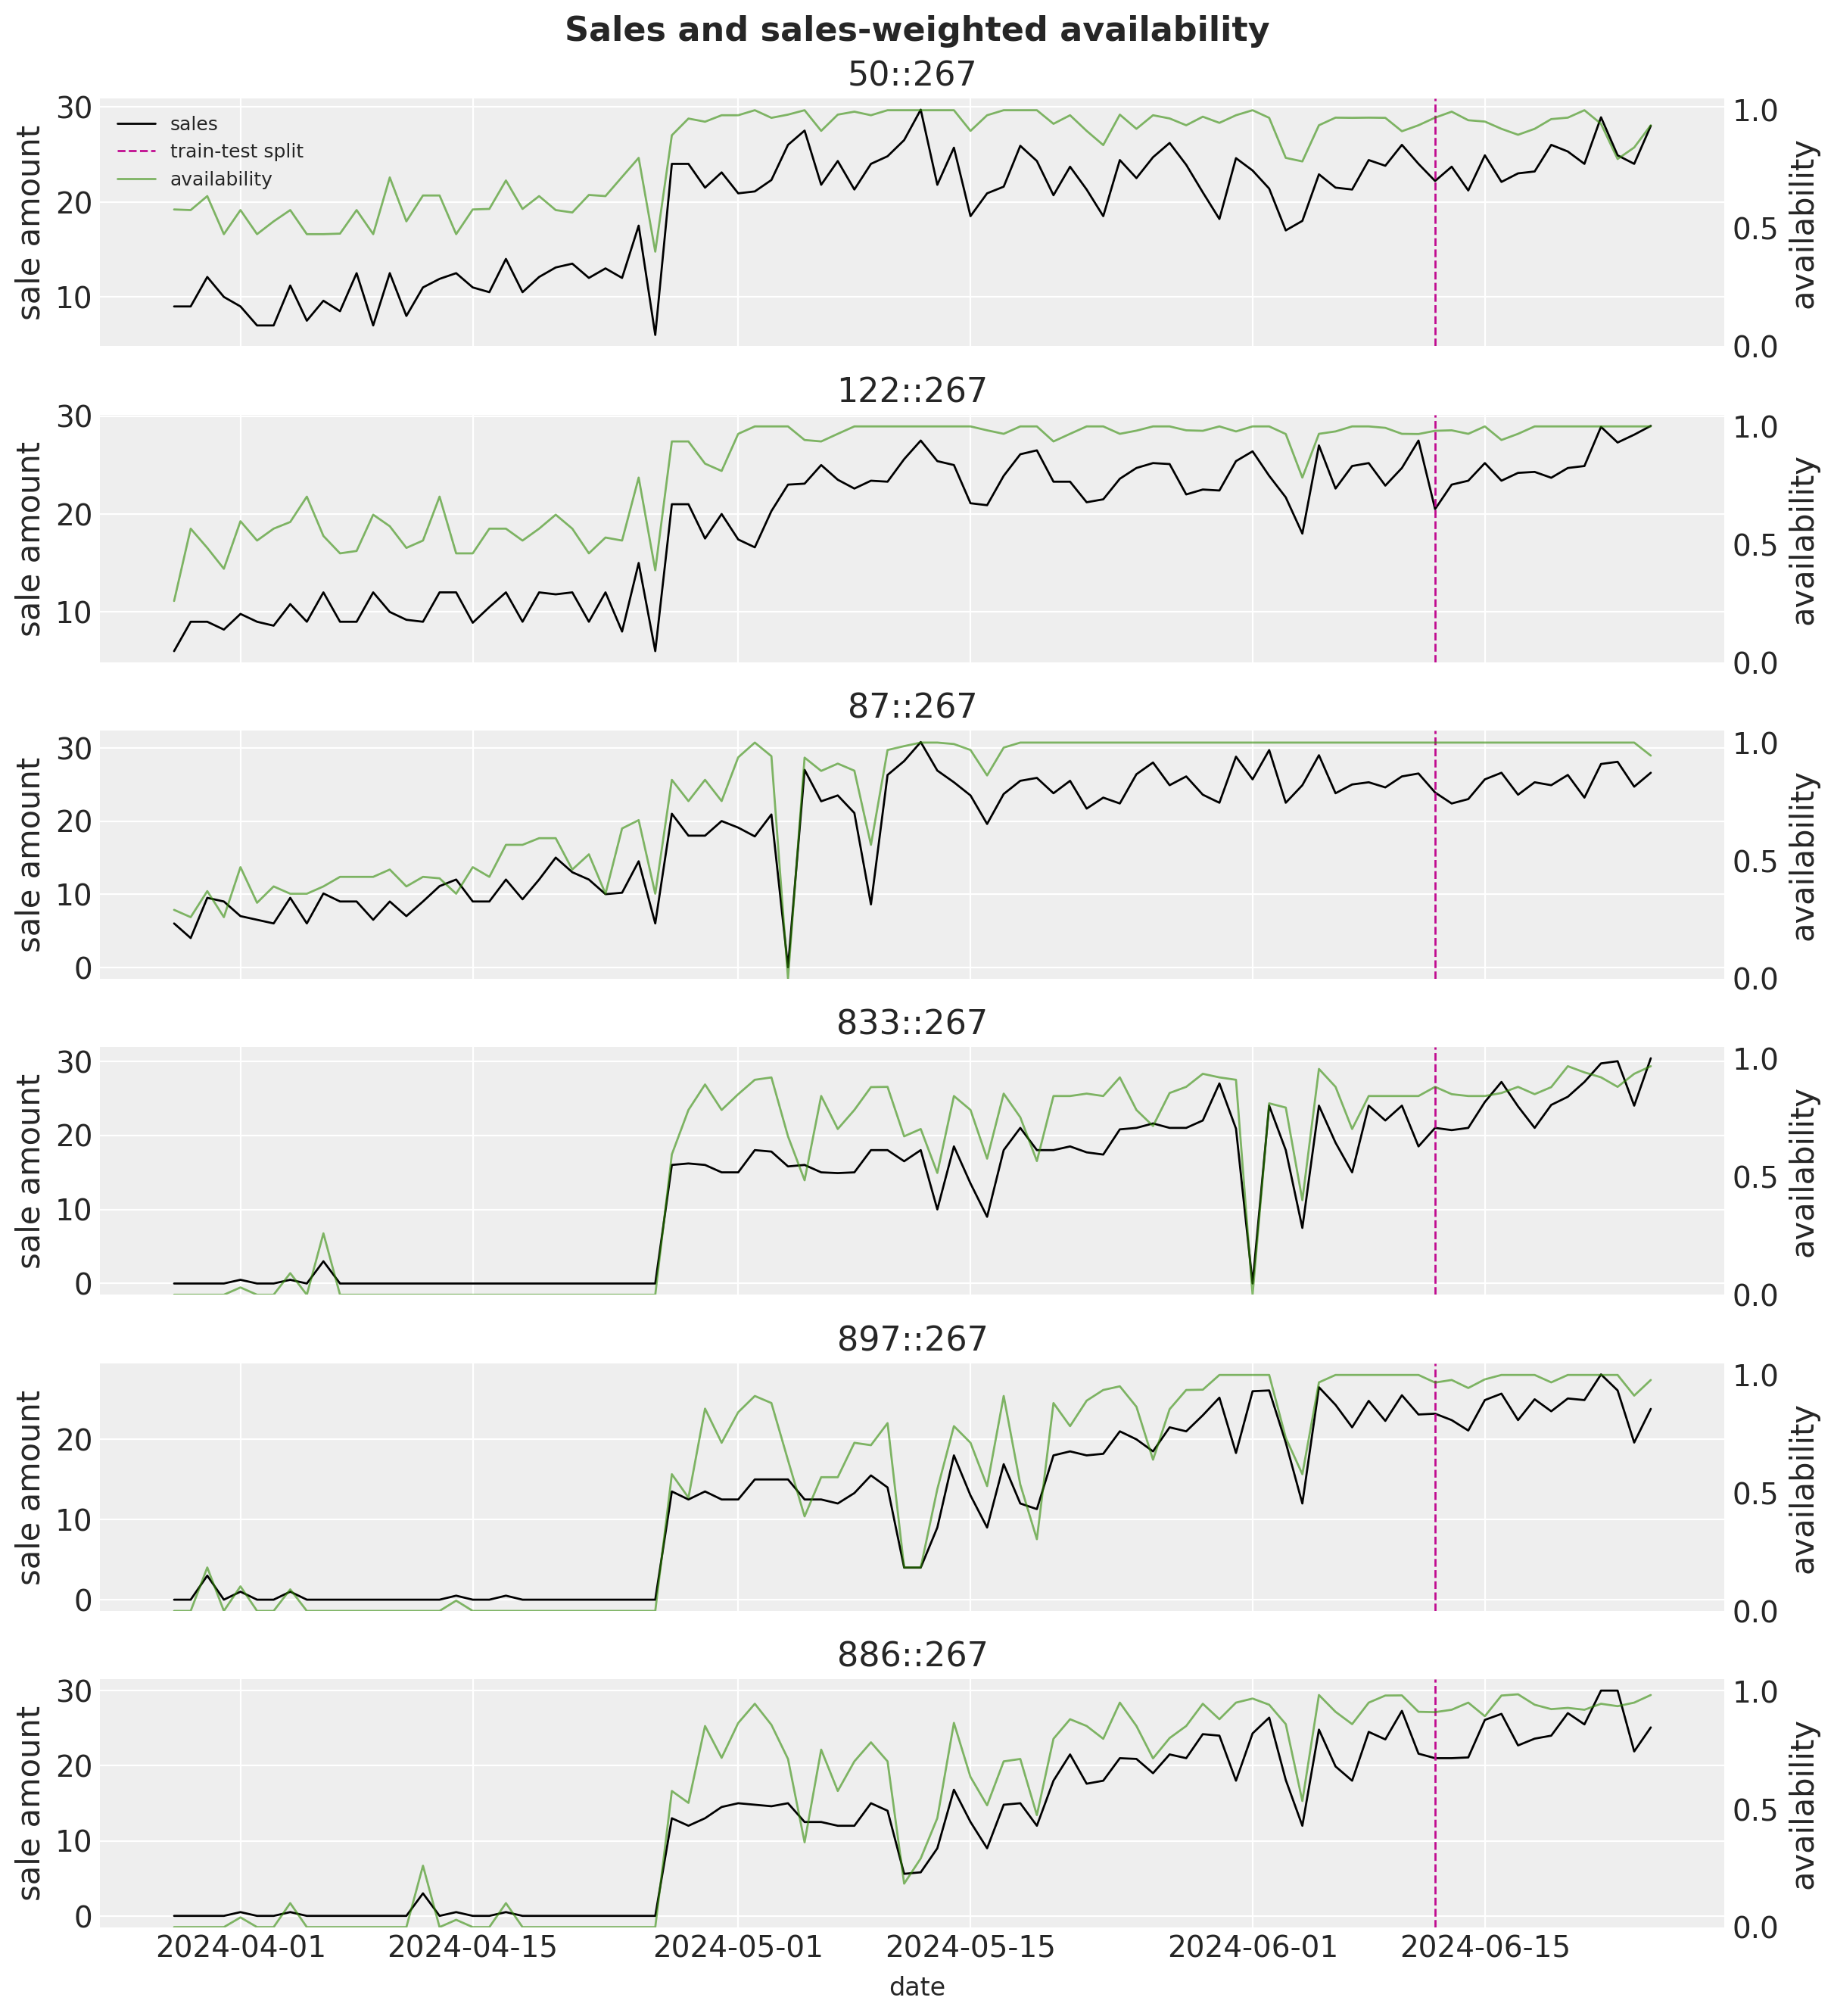

In [15]:
total_sales_per_series = y_full.sum(axis=0)
zero_availability_days = (availability_full == 0.0).sum(axis=0)
top_volume_idx = np.argsort(-total_sales_per_series)[:3]
top_stockout_idx = np.argsort(-zero_availability_days)[:3]
plot_idx = list(dict.fromkeys([*top_volume_idx.tolist(), *top_stockout_idx.tolist()]))
plot_labels = [series_ids[idx] for idx in plot_idx]
split_x = float(mdates.date2num(dates[t_train]))
# plot_lm concatenates x with the float predictions internally, so the faceted
# plots below use matplotlib date numbers plus a date formatter on each axis.
dates_num = np.asarray(mdates.date2num(dates))

fig, axes = plt.subplots(
    nrows=len(plot_idx),
    figsize=(12, 2.2 * len(plot_idx)),
    sharex=True,
    layout="constrained",
)
for ax, idx in zip(axes, plot_idx, strict=True):
    (sales_line,) = ax.plot(dates, y_full[:, idx], color="black", linewidth=1, label="sales")
    split_line = ax.axvline(
        split_x, color="C3", linestyle="--", linewidth=1, label="train-test split"
    )
    ax.set(title=series_ids[idx], ylabel="sale amount")
    ax_twin = ax.twinx()
    (availability_line,) = ax_twin.plot(
        dates, availability_full[:, idx], color="C2", alpha=0.6, linewidth=1, label="availability"
    )
    ax_twin.grid(False)
    ax_twin.set(ylabel="availability", ylim=(0, 1.05))
axes[0].legend(handles=[sales_line, split_line, availability_line], loc="upper left", fontsize=9)
fig.suptitle("Sales and sales-weighted availability", fontsize=16, fontweight="bold")
fig.supxlabel("date")

The stockout-heavy series make the modeling problem vivid: sales collapse toward zero when availability drops, but not exactly to zero, and they snap back as soon as stock returns.

## Model specification

The model is a panel state space model on the scaled sales, with four components per series $s$:

- a random-walk local level for the slow demand trend,
- a zero-sum weekly seasonal profile,
- promotion and calendar effects pooled hierarchically by store,
- a multiplicative availability factor with a learned floor, which also scales the observation noise.

$$
\begin{align*}
y_{t,s} &\sim \text{Normal}\left(f_{t,s} \, \mu_{t,s},\; f_{t,s} \, \sigma_s + \sigma_0\right) \\
\mu_{t,s} &= \ell_{t,s} + \gamma_{d(t),s} + \sum_{c=1}^{3} \beta_{c,s} \, x_{c,t,s} \\
\ell_{t,s} &= \ell_{0,s} + \sum_{u \le t} \varepsilon_{u,s}, \qquad \varepsilon_{u,s} \sim \text{Normal}(0, \tau_s) \\
f_{t,s} &= \phi_s + (1 - \phi_s) \, \frac{1 - e^{-b_s a_{t,s}}}{1 - e^{-b_s}} \\
\beta_{c,s} &\sim \text{Normal}\left(\mu^{\text{store}}_{c,\,m(s)},\; \sigma^{\text{store}}_{c,\,m(s)}\right)
\end{align*}
$$

where $d(t)$ is the day of week, $m(s)$ the store of series $s$, and $a_{t,s}$ the sales-weighted availability. The random-walk drift $\varepsilon$ and the coefficients $\beta$ use `LocScaleReparam` with learned centeredness parameters, as in the other hierarchical examples.

### The availability factor

The factor $f_{t,s}$ deserves a close look, because its three ingredients each fix a concrete failure mode:

- **The floor $\phi_s \in (0, 1)$.** At zero recorded availability the factor equals $\phi_s$, not zero, so the $15\%$ of flagged stockout days with positive sales are explained by a small expected sale instead of blowing up the likelihood. The prior $\phi_s \sim \text{Beta}(2, 18)$ (mean $0.1$) is informed by the empirical floor of about $0.04$ measured above, while staying wide enough for series with sloppier labels.
- **The saturating link $1 - e^{-b_s a}$.** This is the classic random-encounter (reach) curve: if purchase attempts arrive through the day at rate $b_s$ per unit of sales-weighted availability, the probability that an attempt lands in an in-stock window is exactly $1 - e^{-b_s a}$. It matches the concave shape of the empirical curve, and compared to alternatives such as $\tanh$ it is cheaper (one exponential), has a smooth monotone gradient in $b_s$, and gives $b_s$ a direct interpretation as purchase-opportunity intensity.
- **The normalization by $1 - e^{-b_s}$.** Without it, the factor at full availability is $1 - e^{-b_s} < 1$, and the model can trade the factor's overall scale against the level $\ell_{t,s}$ (multiply one, divide the other), leaving both non-identified. Anchoring $f_{t,s} = 1$ at $a = 1$ removes that degeneracy: the level is the demand at full availability, $\phi_s$ is exactly the share of demand still sold on a fully flagged-out day, and $b_s$ only controls the curvature. Numerically we compute the ratio with `expm1`, which is exact as $b_s \to 0$ where the naive expression degrades to $0/0$.

Finally, the noise scale is $f_{t,s} \sigma_s + \sigma_0$: stockout days have proportionally smaller spread (sales are pinned near zero), plus a small *constant* basal term $\sigma_0 = 0.02$ on the scaled axis. The constant is a deliberate choice, learned the hard way: many series sell exactly zero on their stockout days, and if the basal noise is a learned parameter the ELBO can push the total scale toward zero at those exact-zero observations (a Normal density at a perfectly fit point grows without bound as its scale shrinks), which eventually overflows to `NaN` mid-optimization. A fixed $\sigma_0$ bounds the likelihood and costs nothing: it is well below one physical sale unit for every series in the panel (one unit is between $0.06$ and $0.29$ on the scaled axis).

In [16]:
class FreshRetailModel(ForecastingModel):
    """Hierarchical panel model with a floored multiplicative availability factor.

    Parameters
    ----------
    series_to_store
        Integer index mapping each series to its store, shape ``(n_series,)``.
    n_stores
        Number of distinct stores in the panel.
    n_series
        Number of store-product series (the trailing observation axis).
    n_cov
        Number of regression features (excluding availability).
    """

    def __init__(
        self,
        series_to_store: Int[Array, " n_series"],
        n_stores: int,
        n_series: int,
        n_cov: int,
    ) -> None:
        super().__init__()
        self.series_to_store = series_to_store
        self.n_stores = n_stores
        self.n_series = n_series
        self.n_cov = n_cov

    def model(
        self,
        zero_data: Float[Array, " duration n_series"] | None,
        covariates: Float[Array, " duration packed_dim"],
    ) -> None:
        """Sample the joint model (the package calls this for training and forecasting)."""
        duration = covariates.shape[-2]
        packed = covariates.reshape(duration, self.n_cov + 1, self.n_series)
        availability = packed[:, 0, :]
        features = jnp.moveaxis(packed[:, 1:, :], 1, 0)

        # Global hyperpriors. The seasonal scale must be a scalar because
        # ZeroSumNormal cannot broadcast a per-series scale over the plate.
        centered_drift = numpyro.sample("centered_drift", dist.Uniform(0.0, 1.0))
        centered_b = numpyro.sample("centered_b", dist.Uniform(0.0, 1.0))
        seasonal_scale = numpyro.sample("seasonal_scale", dist.HalfNormal(0.2))

        with numpyro.plate("store", self.n_stores, dim=-1):
            with numpyro.plate("covariate", self.n_cov, dim=-2):
                b_loc_store = cast("Array", numpyro.sample("b_loc_store", dist.Normal(0.0, 0.5)))
                b_scale_store = cast(
                    "Array", numpyro.sample("b_scale_store", dist.HalfNormal(0.3))
                )

        with numpyro.plate("series", self.n_series, dim=-1):
            drift_scale = numpyro.sample("drift_scale", dist.LogNormal(-3.0, 1.0))
            init_level = cast("Array", numpyro.sample("init_level", dist.Normal(1.0, 0.5)))
            b_avail = cast("Array", numpyro.sample("b_avail", dist.LogNormal(1.0, 0.5)))
            floor = cast("Array", numpyro.sample("floor", dist.Beta(2.0, 18.0)))
            sigma = cast("Array", numpyro.sample("sigma", dist.HalfNormal(0.5)))
            seasonal = cast(
                "Array",
                numpyro.sample("seasonal", dist.ZeroSumNormal(seasonal_scale, event_shape=(7,))),
            )
            with numpyro.plate("covariate", self.n_cov, dim=-2):
                with handlers.reparam(config={"b": LocScaleReparam(centered=centered_b)}):
                    b = cast(
                        "Array",
                        numpyro.sample(
                            "b",
                            dist.Normal(
                                b_loc_store[:, self.series_to_store],
                                b_scale_store[:, self.series_to_store],
                            ),
                        ),
                    )
            # time_series opens its own time plate at dim=-2, so the covariate
            # plate above must already be closed here.
            drift = self.time_series(
                "drift",
                lambda: dist.Normal(0.0, drift_scale),
                reparam=LocScaleReparam(centered=centered_drift),
            )

        level = init_level + jnp.cumsum(drift, axis=-2)
        seasonal_rep = periodic_repeat(seasonal.T, duration, axis=-2)
        covariates_contribution = (features * b[:, None, :]).sum(axis=0)
        saturation = jnp.expm1(-b_avail * availability) / jnp.expm1(-b_avail)
        factor = floor + (1.0 - floor) * saturation
        mu = factor * (level + seasonal_rep + covariates_contribution)
        # The constant basal noise bounds the likelihood at exact-zero sales;
        # a learned basal term can collapse there and NaN the optimization.
        sigma_t = factor * sigma + 0.02
        self.predict_glm(lambda m: dist.Normal(m, sigma_t), mu)


model = FreshRetailModel(
    series_to_store=series_to_store,
    n_stores=n_stores,
    n_series=n_series,
    n_cov=n_covariates,
)

Let's visualize the model structure:

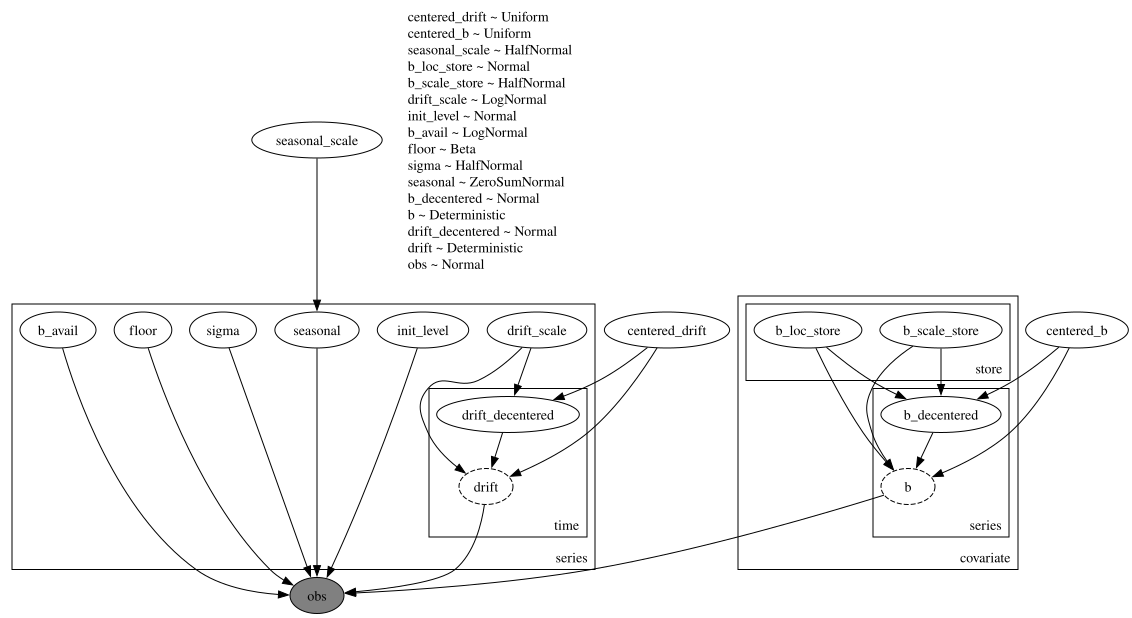

In [17]:
numpyro.render_model(
    model,
    model_args=(covariates_train, y_train),
    render_distributions=True,
)

## Prior predictive checks

First the factor itself: the priors on $\phi_s$ and $b_s$ should cover both gentle and sharp saturation, with the floor concentrated near the empirical value but not glued to it.

[Text(0.5, 0, 'sales-weighted availability'),
 Text(0, 0.5, 'availability factor'),
 Text(0.5, 1.0, 'Prior availability factor curves')]

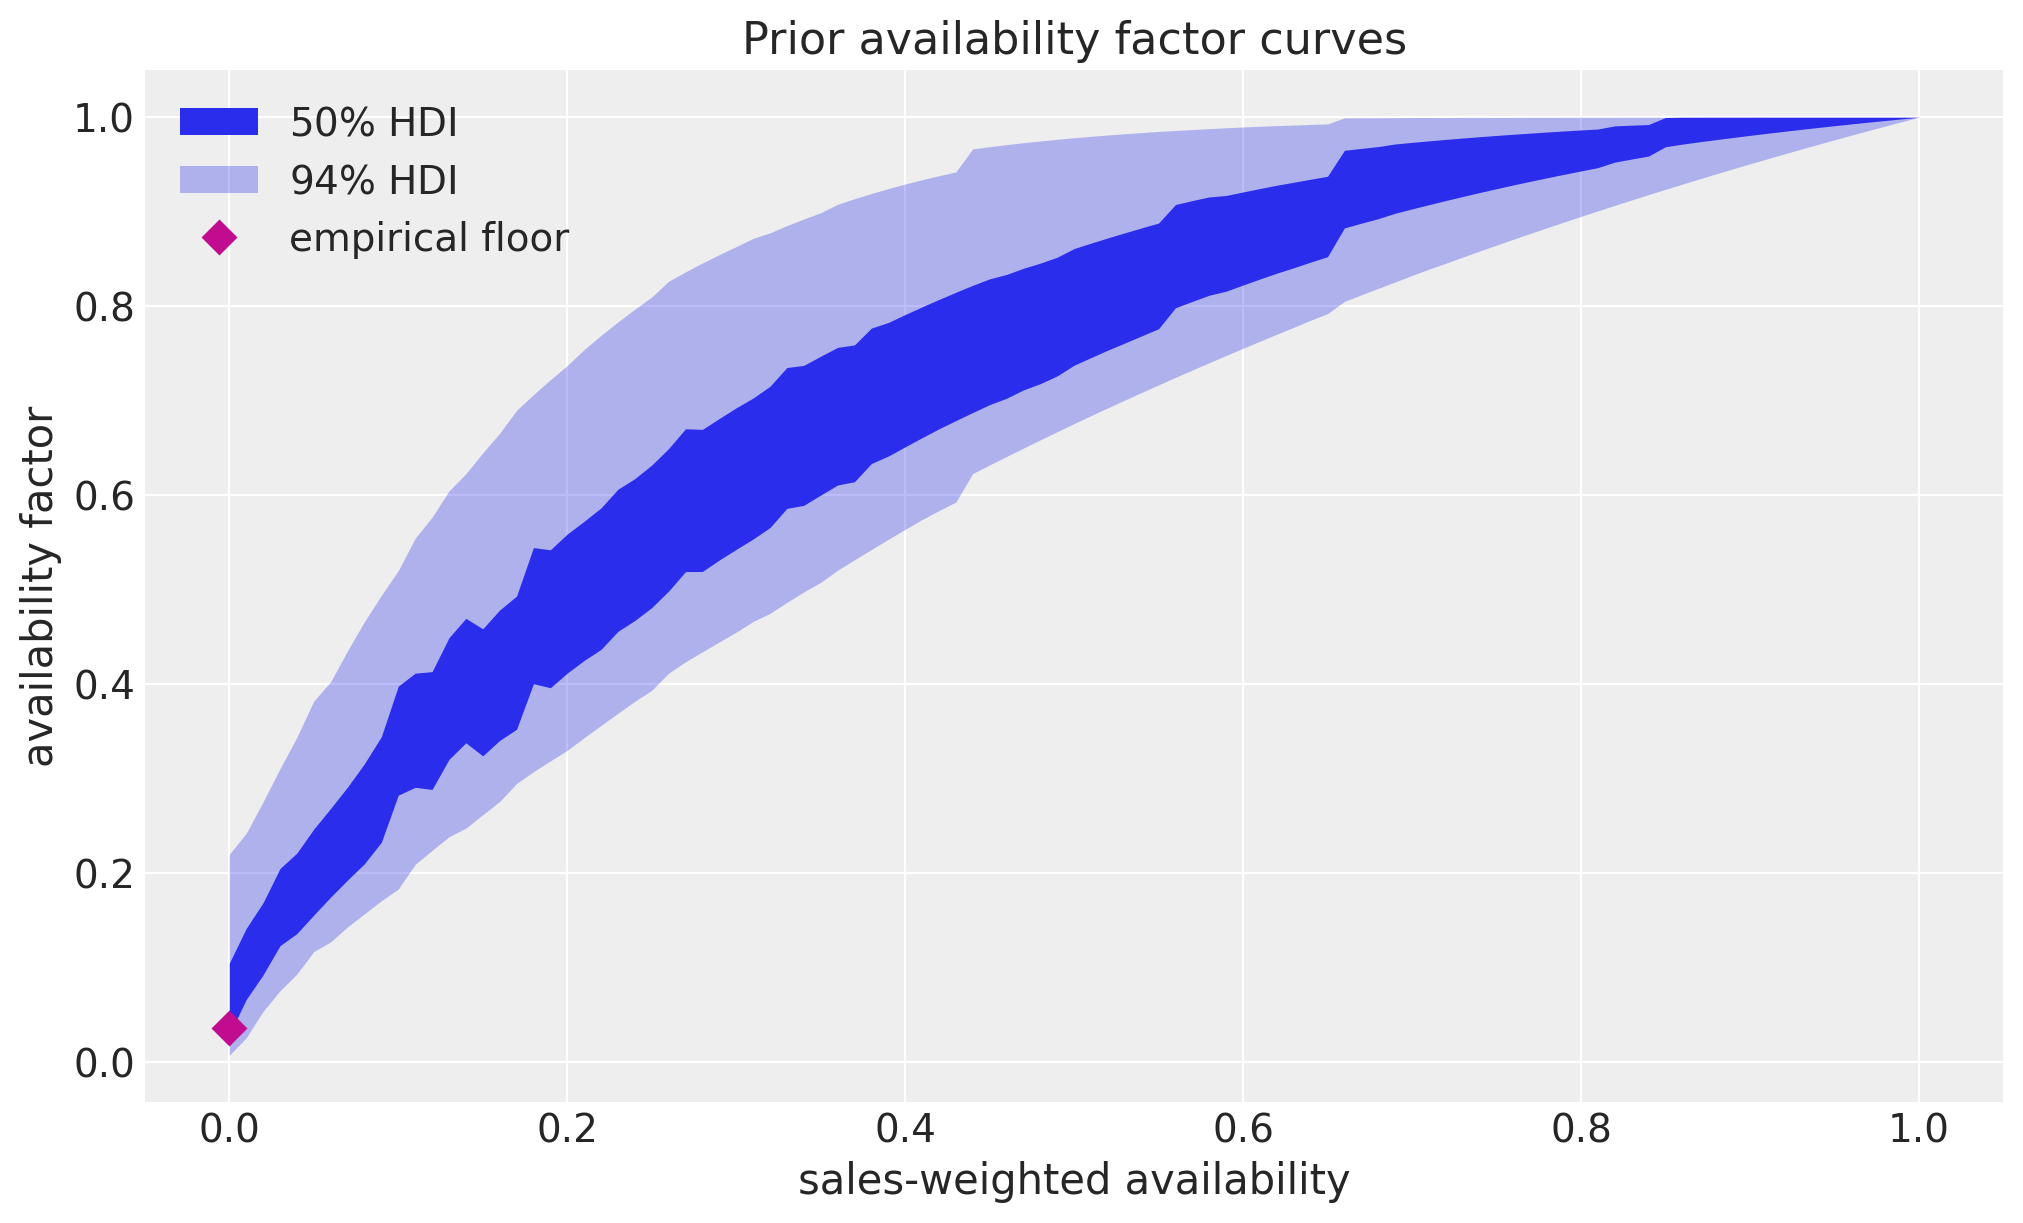

In [18]:
def faceted_idata(
    obs: Float[np.ndarray, " sample time n_plot"],
    t: np.ndarray,
    labels: list[str],
    group: str = "posterior_predictive",
) -> xr.DataTree:
    """Pack ``(draws, time, series)`` predictions into a DataTree for `plot_lm` faceting.

    The independent variable in ``constant_data`` carries the ``series`` dimension so
    that `plot_lm` facets one panel per series (``plot_dim="time"``).
    """
    x_grid = np.broadcast_to(np.asarray(t)[:, None], obs.shape[1:])
    return az.from_dict(
        {
            group: {"obs": obs[None]},
            "observed_data": {"obs": np.zeros(obs.shape[1:])},
            "constant_data": {"t": x_grid},
        },
        coords={"time": t, "series": labels},
        dims={"obs": ["time", "series"], "t": ["time", "series"]},
    )


availability_grid = np.linspace(0.0, 1.0, 101)
rng_key, key_floor, key_b = random.split(rng_key, 3)
floor_prior = dist.Beta(2.0, 18.0).sample(key_floor, (500,))
b_prior = dist.LogNormal(1.0, 0.5).sample(key_b, (500,))
grid_jax = jnp.asarray(availability_grid, dtype=jnp.float32)
saturation_prior = jnp.expm1(-b_prior[:, None] * grid_jax) / jnp.expm1(-b_prior[:, None])
factor_prior = floor_prior[:, None] + (1.0 - floor_prior[:, None]) * saturation_prior

pc = az.plot_lm(
    faceted_idata(
        np.asarray(factor_prior)[:, :, None],
        availability_grid,
        ["prior factor"],
        group="prior_predictive",
    ),
    y="obs",
    x="t",
    plot_dim="time",
    group="prior_predictive",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={
        "ci_band": {"color": "C0"},
        "observed_scatter": False,
        "pe_line": False,
        "xlabel": False,
        "ylabel": False,
    },
    figure_kwargs={"figsize": (10, 6)},
)
ax = pc.get_target("t", {"series": "prior factor"})
ax.plot(0.0, empirical_floor, "D", color="C3", markersize=8, label="empirical floor")
bands = pc.viz["ci_band"]["t"].sel(series="prior factor")
band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
band_94.set_label(r"$94\%$ HDI")
band_50.set_label(r"$50\%$ HDI")
ax.legend(loc="upper left")
ax.set(
    xlabel="sales-weighted availability",
    ylabel="availability factor",
    title="Prior availability factor curves",
)

Next the full prior predictive on the training window for our six focus series, with the scaled observations overlaid. We want wide but sane bands on the unit scale of the normalized data.

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_13769/1414740210.py:64: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


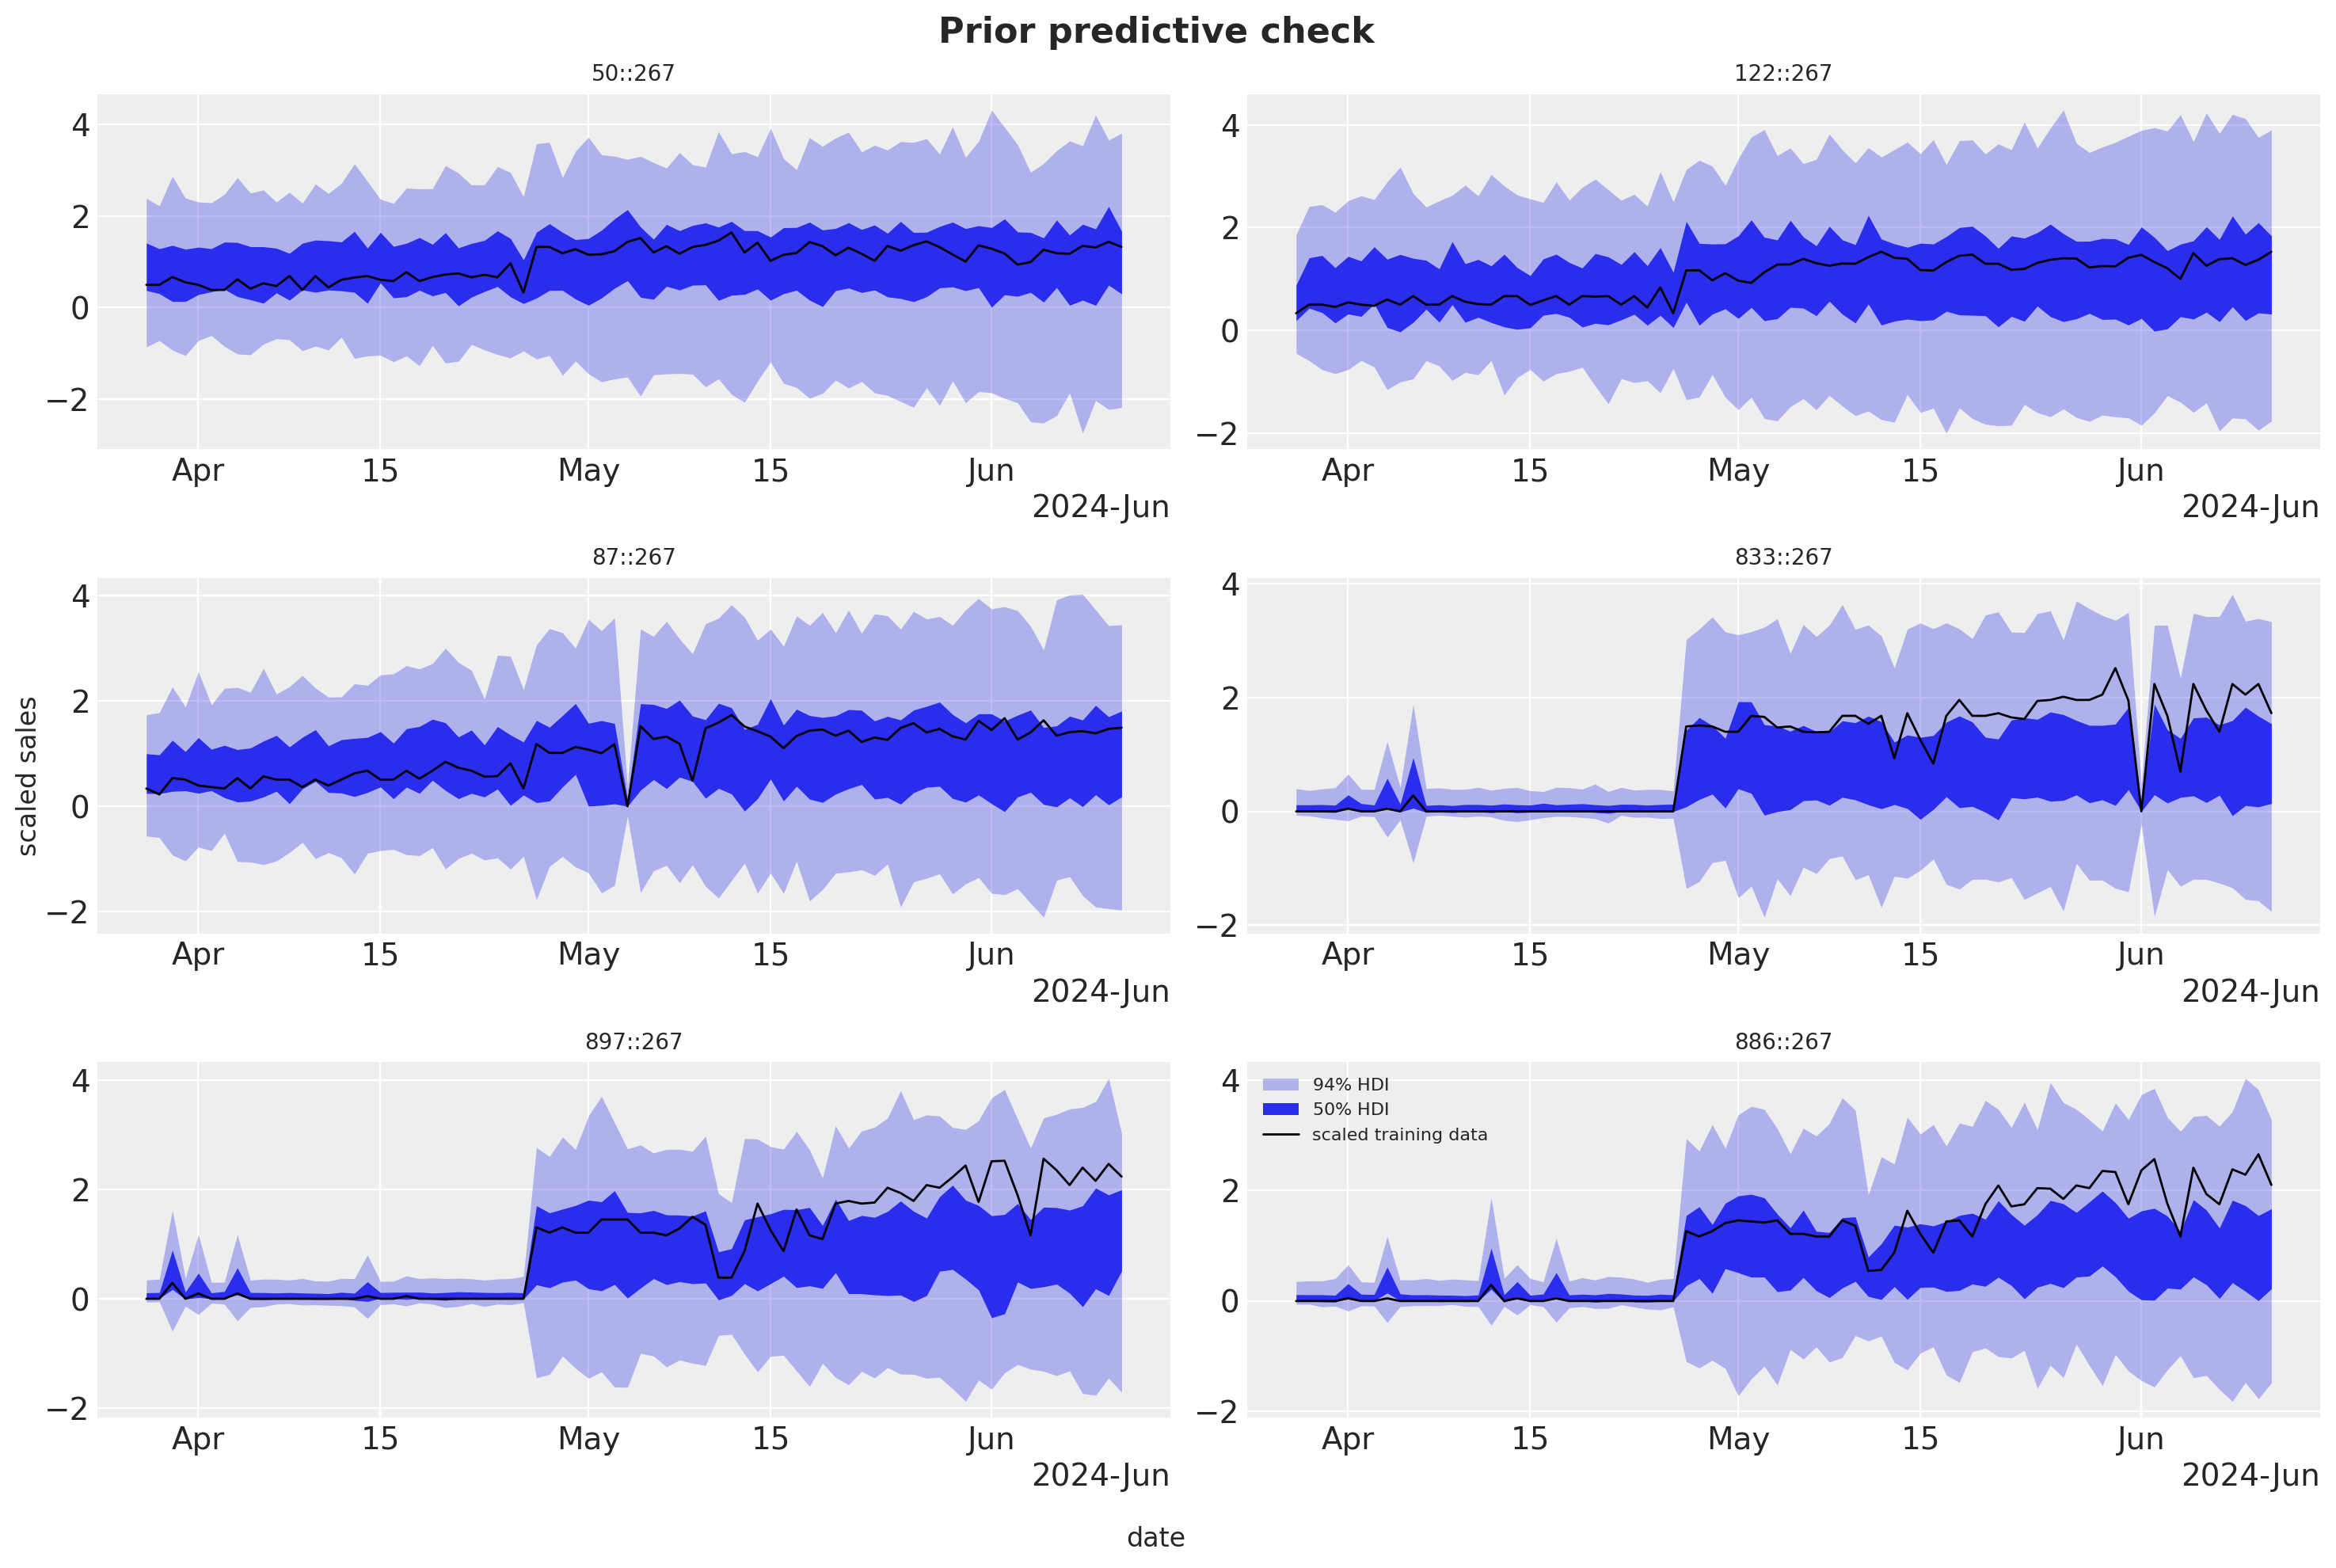

In [19]:
rng_key, key_prior = random.split(rng_key)
prior_obs = Predictive(model, num_samples=500, return_sites=["obs"])(key_prior, covariates_train)[
    "obs"
]

pc = az.plot_lm(
    faceted_idata(
        np.asarray(prior_obs)[:, :, plot_idx],
        dates_num[:t_train],
        plot_labels,
        group="prior_predictive",
    ),
    y="obs",
    x="t",
    plot_dim="time",
    group="prior_predictive",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    col_wrap=2,
    visuals={
        "ci_band": {"color": "C0"},
        "observed_scatter": False,
        "pe_line": False,
        "xlabel": False,
        "ylabel": False,
    },
    figure_kwargs={"figsize": (15, 10)},
)
truth_da = xr.DataArray(
    np.asarray(y_train)[:, plot_idx],
    dims=["time", "series"],
    coords={"time": dates_num[:t_train], "series": plot_labels},
    name="t",
)
x_da = xr.DataArray(dates_num[:t_train], dims=["time"], coords={"time": dates_num[:t_train]})
pc.map(
    az.visuals.line_xy,
    "truth",
    data=truth_da,
    x=x_da,
    ignore_aes=pc.aes_set,
    color="black",
    lw=1,
)
for label in plot_labels:
    ax = pc.get_target("t", {"series": label})
    ax.set_title(label, fontsize=10)
    locator = mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax0 = pc.get_target("t", {"series": plot_labels[-1]})
bands = pc.viz["ci_band"]["t"].sel(series=plot_labels[-1])
band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
band_94.set_label(r"$94\%$ HDI")
band_50.set_label(r"$50\%$ HDI")
truth_line = pc.viz["truth"]["t"].sel(series=plot_labels[-1]).item()
truth_line.set_label("scaled training data")
ax0.legend(handles=[band_94, band_50, truth_line], loc="upper left", fontsize=8)
fig = pc.viz["figure"].item()
fig.supxlabel("date")
fig.supylabel("scaled sales")
fig.suptitle("Prior predictive check", fontsize=16, fontweight="bold")
fig.tight_layout()

## Inference with SVI

We fit with `fit_svi` and its default `AutoNormal` guide. Instead of a fixed learning rate we pass a custom `optax` optimizer, the one-cycle Adam schedule chained with `reduce_on_plateau`, which converges noticeably better on this panel (the same recipe as in the [inference methods comparison](inference_methods_comparison.html) example). The full $10{,}000$ steps take well under a minute on CPU.

In [20]:
num_steps = 10_000

scheduler = optax.linear_onecycle_schedule(
    transition_steps=num_steps,
    peak_value=0.01,
    pct_start=0.3,
    pct_final=0.85,
    div_factor=2,
    final_div_factor=3,
)

optimizer = optax.chain(
    optax.adam(learning_rate=scheduler),
    optax.contrib.reduce_on_plateau(
        factor=0.8,
        patience=20,
        accumulation_size=100,
    ),
)

rng_key, key_fit = random.split(rng_key)
svi_fit = fit_svi(
    key_fit,
    model,
    y_train,
    covariates_train,
    optim=optimizer,
    num_steps=num_steps,
)
jax.block_until_ready(svi_fit.losses)

Array([1.3476027e+07, 1.3116555e+07, 1.2469355e+07, ..., 1.5991141e+04,
       1.5683604e+04, 1.6502287e+04], dtype=float32)

[None,
 Text(0.5, 0, 'SVI step'),
 Text(0, 0.5, 'loss'),
 Text(0.5, 1.0, 'SVI ELBO loss')]

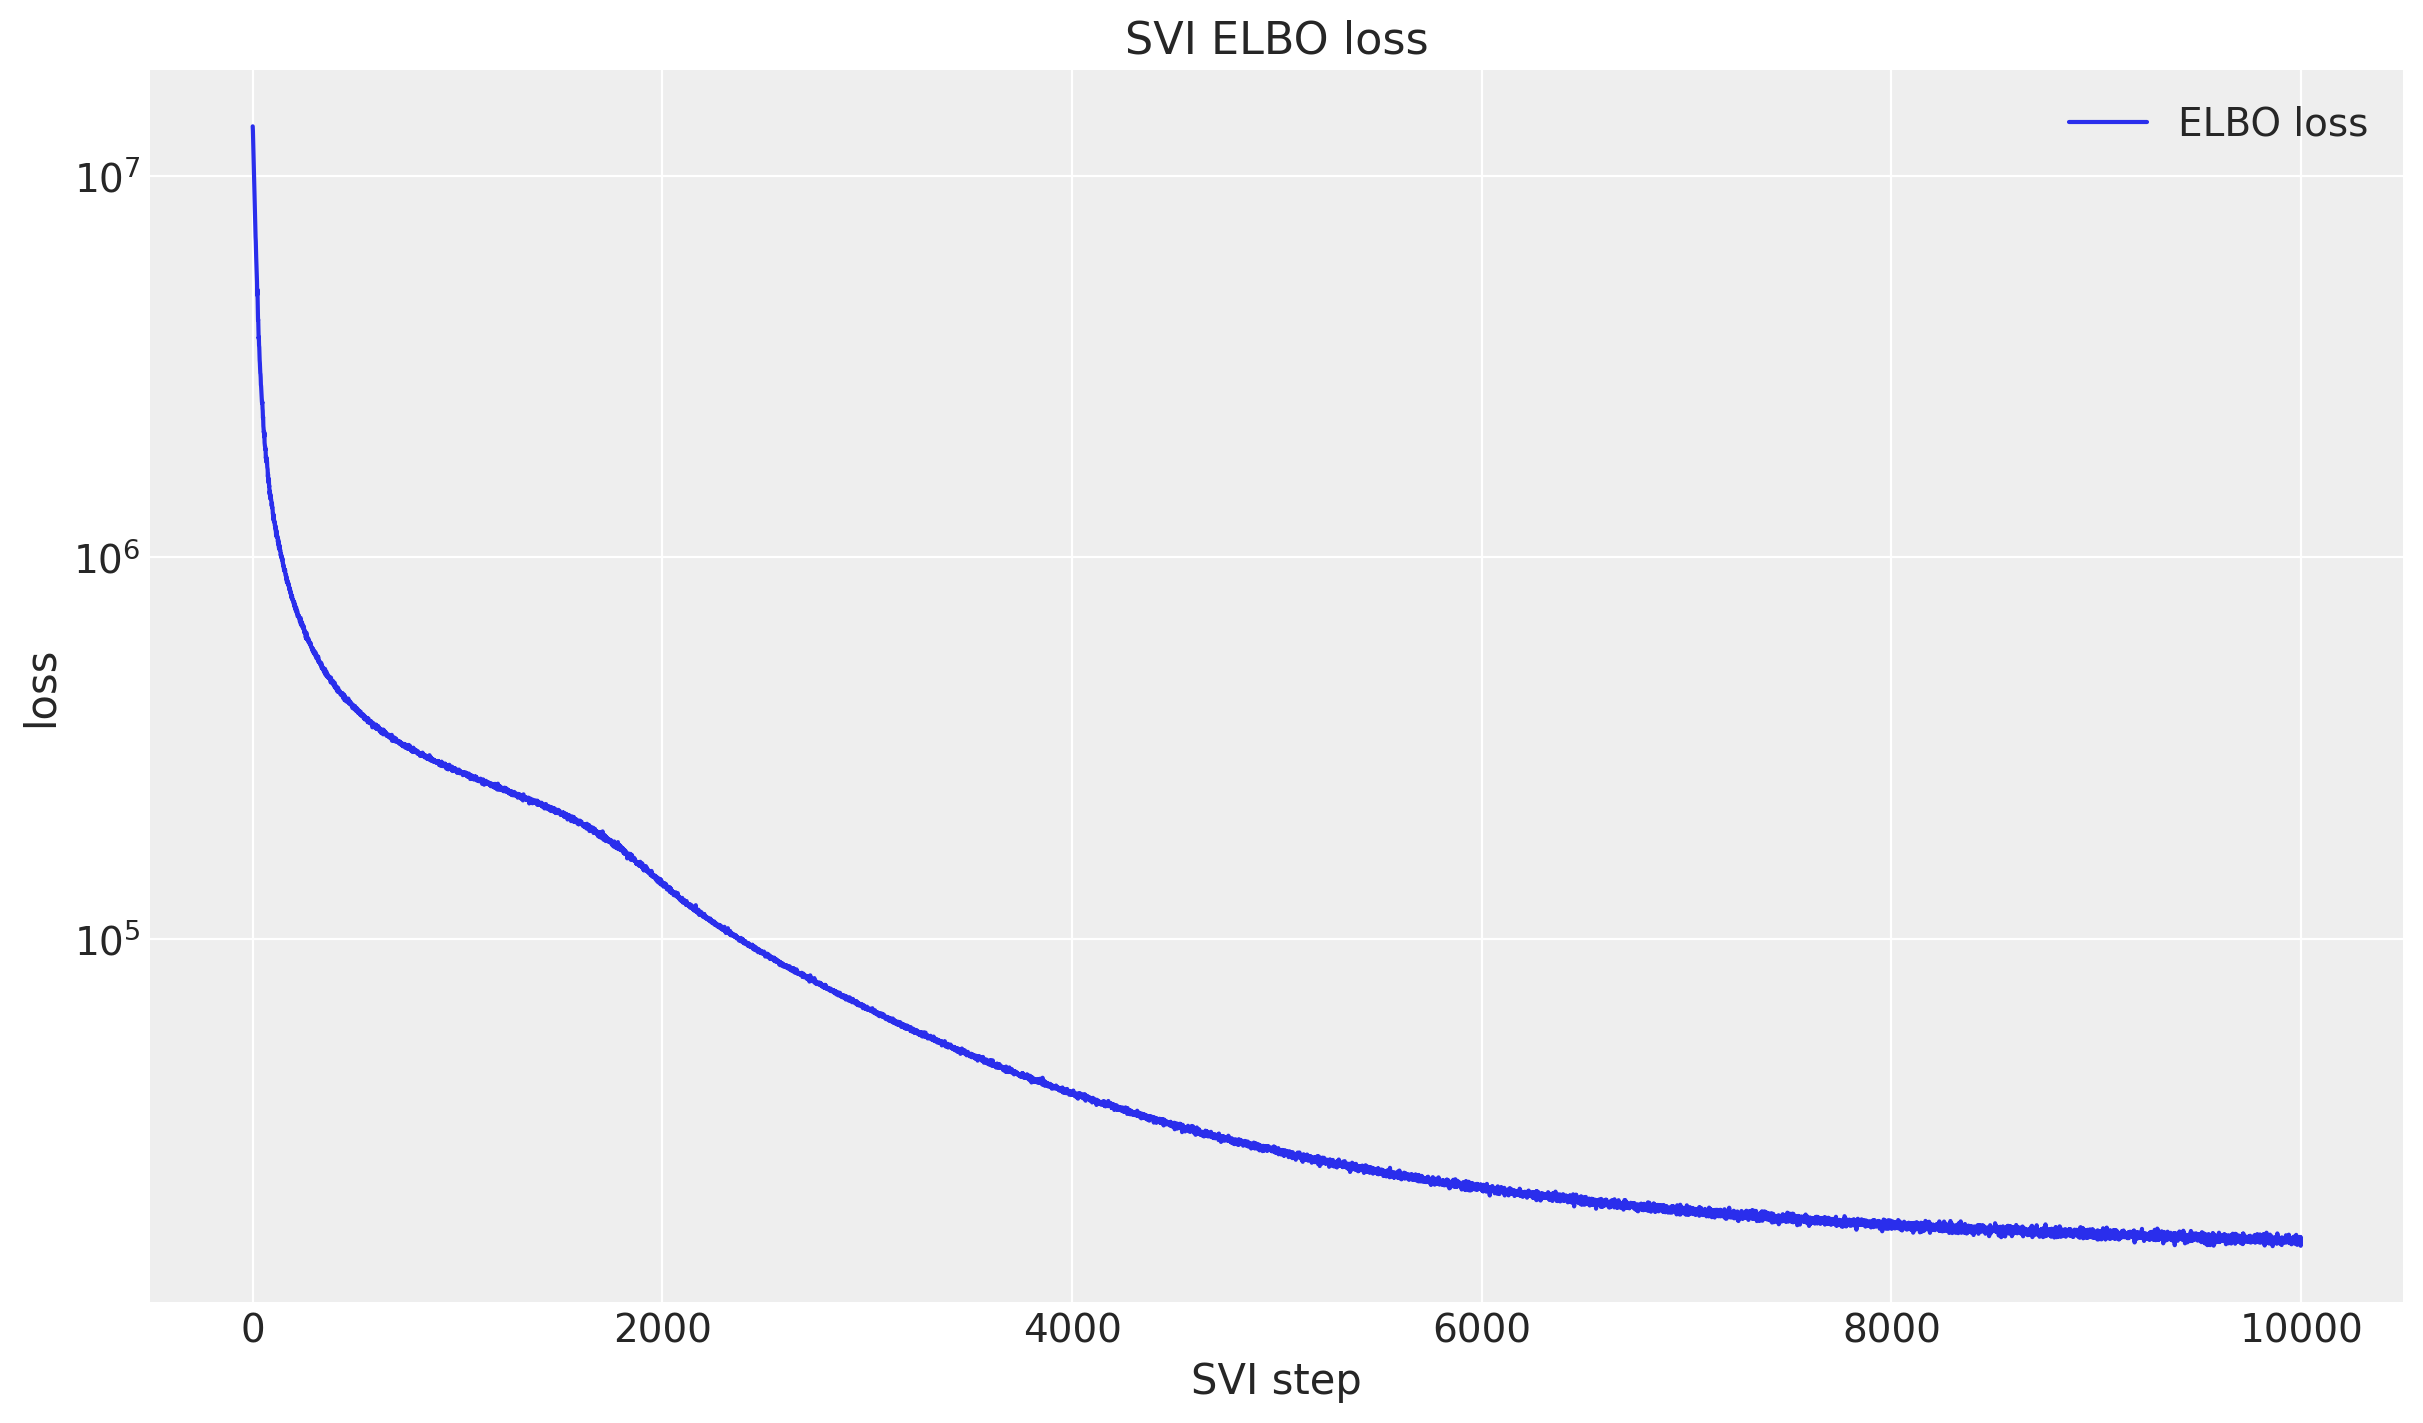

In [21]:
fig, ax = plt.subplots()
ax.plot(np.asarray(svi_fit.losses), color="C0", label="ELBO loss")
ax.legend(loc="upper right")
ax.set(yscale="log", xlabel="SVI step", ylabel="loss", title="SVI ELBO loss")

## Export to an ArviZ DataTree

A single `to_datatree` call wraps everything: it draws the posterior from the guide, runs the in-sample posterior predictive, and, because the covariates extend $14$ days past the training data, also generates the forecast and stores it in the `predictions` group. We label every dimension so downstream selections read naturally.

In [22]:
first_weekday = int(dates_series.dt.weekday()[0])
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_labels = [day_names[(first_weekday - 1 + offset) % 7] for offset in range(7)]

rng_key, key_tree = random.split(rng_key)
tree = to_datatree(
    key_tree,
    svi_fit,
    model,
    y_train,
    covariates,
    num_predictive_samples=500,
    time_coord=list(dates),
    coords={
        "series": series_ids,
        "obs_dim": series_ids,
        "store": store_ids,
        "covariate": covariate_names,
        "day_of_week": dow_labels,
    },
    posterior_dims={
        "drift": ["time", "series"],
        "drift_decentered": ["time", "series"],
        "seasonal": ["series", "day_of_week"],
        "b": ["covariate", "series"],
        "b_decentered": ["covariate", "series"],
        "b_loc_store": ["covariate", "store"],
        "b_scale_store": ["covariate", "store"],
        "drift_scale": ["series"],
        "init_level": ["series"],
        "b_avail": ["series"],
        "floor": ["series"],
        "sigma": ["series"],
    },
)
tree

<xarray.DataTree>
Group: /
│   Attributes:
│       inference_library:  numpyro
│       creation_library:   numpyro_forecast
│       sample_dims:        ['chain', 'draw']
├── Group: /posterior
│       Dimensions:           (chain: 1, draw: 500, covariate: 3, series: 1000,
│                              store: 520, time: 76, day_of_week: 7)
│       Coordinates:
│         * chain             (chain) int64 8B 0
│         * draw              (draw) int64 4kB 0 1 2 3 4 5 6 ... 494 495 496 497 498 499
│         * covariate         (covariate) <U18 216B 'discount_magnitude' ... 'holiday...
│         * series            (series) <U8 32kB '0::117' '0::691' ... '99::589' '9::4'
│         * store             (store) int64 4kB 0 1 2 3 4 5 ... 891 892 893 894 896 897
│         * time              (time) datetime64[s] 608B 2024-03-28 ... 2024-06-11
│         * day_of_week       (day_of_week) <U3 84B 'Thu' 'Fri' 'Sat' ... 'Tue' 'Wed'
│       Data variables: (12/15)
│           b                 (chain, draw, covariate, series) float32 6MB -0.06302 ....
│           b_avail           (chain, draw, series) float32 2MB 0.9401 1.707 ... 14.87
│           b_decentered      (chain, draw, covariate, series) float32 6MB -0.7151 .....
│           b_loc_store       (chain, draw, covariate, store) float32 3MB 0.5581 ... ...
│           b_scale_store     (chain, draw, covariate, store) float32 3MB 0.4422 ... ...
│           centered_b        (chain, draw) float32 2kB 0.455 0.4601 ... 0.4598 0.4637
│           ...                ...
│           drift_scale       (chain, draw, series) float32 2MB 0.008149 ... 0.01383
│           floor             (chain, draw, series) float32 2MB 0.06866 ... 0.02562
│           init_level        (chain, draw, series) float32 2MB 1.035 0.9778 ... 0.7092
│           seasonal          (chain, draw, series, day_of_week) float32 14MB -0.0181...
│           seasonal_scale    (chain, draw) float32 2kB 0.06236 0.06263 ... 0.06206
│           sigma             (chain, draw, series) float32 2MB 0.2409 0.2119 ... 0.5394
│       Attributes:
│           created_at:                 2026-07-09T07:42:38.879411+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           variational:                True
├── Group: /posterior_predictive
│       Dimensions:  (chain: 1, draw: 500, time: 76, obs_dim: 1000)
│       Coordinates:
│         * chain    (chain) int64 8B 0
│         * draw     (draw) int64 4kB 0 1 2 3 4 5 6 7 ... 493 494 495 496 497 498 499
│         * time     (time) datetime64[s] 608B 2024-03-28 2024-03-29 ... 2024-06-11
│         * obs_dim  (obs_dim) <U8 32kB '0::117' '0::691' '0::70' ... '99::589' '9::4'
│       Data variables:
│           obs      (chain, draw, time, obs_dim) float32 152MB 0.09036 0.959 ... 0.9145
│       Attributes:
│           created_at:                 2026-07-09T07:42:39.551112+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:  (time: 76, obs_dim: 1000)
│       Coordinates:
│         * time     (time) datetime64[s] 608B 2024-03-28 2024-03-29 ... 2024-06-11
│         * obs_dim  (obs_dim) <U8 32kB '0::117' '0::691' '0::70' ... '99::589' '9::4'
│       Data variables:
│           obs      (time, obs_dim) float32 304kB 0.06142 0.8523 1.193 ... 1.541 0.3627
│       Attributes:
│           created_at:                 2026-07-09T07:42:39.551600+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                []
├── Group: /constant_data
│       Dimensions:        (time: 76, covariate_dim: 4000)
│       Coordinates:
│         * time           (time) da

## Forecast evaluation: CRPS and coverage

We score on the original sales scale (rescaling the draws by each series' training mean and clipping negatives at zero, since sales are non-negative). CRPS is a proper scoring rule for probabilistic forecasts that generalizes the mean absolute error; coverage checks calibration by asking how often the central $94\%$ and $50\%$ intervals contain the truth. As a reference point we use a seasonal-naive ensemble: the weekday-aligned $14$-day windows from the training data, stacked as an empirical forecast distribution.

In [23]:
def seasonal_naive_ensemble(
    y_history: Float[np.ndarray, " t_hist n_series"],
    horizon: int,
    period: int = 7,
) -> Float[np.ndarray, " n_windows horizon n_series"]:
    """Stack weekday-aligned historical windows as an empirical forecast ensemble.

    Window ``k`` starts ``k * period`` days before the end of the history and spans
    ``horizon`` days, so every window is weekday-aligned with the forecast window.
    """
    t_hist = y_history.shape[0]
    windows = []
    k = 1
    while t_hist - k * period >= 0:
        start = t_hist - k * period
        if start + horizon <= t_hist:
            windows.append(y_history[start : start + horizon])
        k += 1
    return np.stack(windows)


def metrics_table(
    pred_train: Float[Array, " sample t_train n_series"],
    pred_test: Float[Array, " sample horizon n_series"],
    naive_test: Float[Array, " n_windows horizon n_series"],
    y_train_true: Float[Array, " t_train n_series"],
    y_test_true: Float[Array, " horizon n_series"],
) -> pl.DataFrame:
    """Build the CRPS and coverage summary for train, test, and the naive baseline.

    All inputs are on the original sales scale; coverage is not meaningful for the
    small naive ensemble, so its cells stay null.
    """
    return pl.DataFrame(
        {
            "split": ["model (train)", "model (test)", "seasonal naive (test)"],
            "crps": [
                float(eval_crps(pred_train, y_train_true)),
                float(eval_crps(pred_test, y_test_true)),
                float(eval_crps(naive_test, y_test_true)),
            ],
            "coverage_94": [
                float(eval_coverage(pred_train, y_train_true, alpha=0.94)),
                float(eval_coverage(pred_test, y_test_true, alpha=0.94)),
                None,
            ],
            "coverage_50": [
                float(eval_coverage(pred_train, y_train_true, alpha=0.5)),
                float(eval_coverage(pred_test, y_test_true, alpha=0.5)),
                None,
            ],
        }
    )


pp_scaled = jnp.asarray(tree["posterior_predictive"]["obs"].values).reshape(-1, t_train, n_series)
fc_scaled = jnp.asarray(tree["predictions"]["obs"].values).reshape(-1, horizon, n_series)
pred_train = jnp.clip(pp_scaled * scale_jax[None, None, :], min=0.0)
pred_test = jnp.clip(fc_scaled * scale_jax[None, None, :], min=0.0)
naive_test = jnp.asarray(
    seasonal_naive_ensemble(y_full[:t_train], horizon=horizon), dtype=jnp.float32
)

results_df = metrics_table(pred_train, pred_test, naive_test, y_train_original, y_test_original)
crps_test_model = float(results_df["crps"][1])
crps_test_naive = float(results_df["crps"][2])
results_df

split,crps,coverage_94,coverage_50
str,f64,f64,f64
"""model (train)""",0.854327,0.962329,0.609803
"""model (test)""",1.388338,0.829714,0.391571
"""seasonal naive (test)""",2.387625,null,null


The model beats the seasonal-naive baseline on test CRPS by a wide margin. The coverage columns tell a more nuanced story that is worth reading honestly: on the training window the intervals are at or somewhat above their nominal levels, but on the holdout they are too narrow. This is the classic signature of a mean-field variational fit (the `AutoNormal` guide underestimates posterior spread) combined with a random-walk fan-out that can only be as wide as the volatility seen in $76$ training days. We report the raw SVI intervals as they are; conformal-style interval scaling on a held-out window is the standard post-hoc fix and is listed in the next steps. The per-day breakdown shows where the CRPS margin comes from:

[Text(0.5, 0, 'forecast day'),
 Text(0, 0.5, 'mean CRPS'),
 Text(0.5, 1.0, 'Test CRPS by forecast horizon day'),

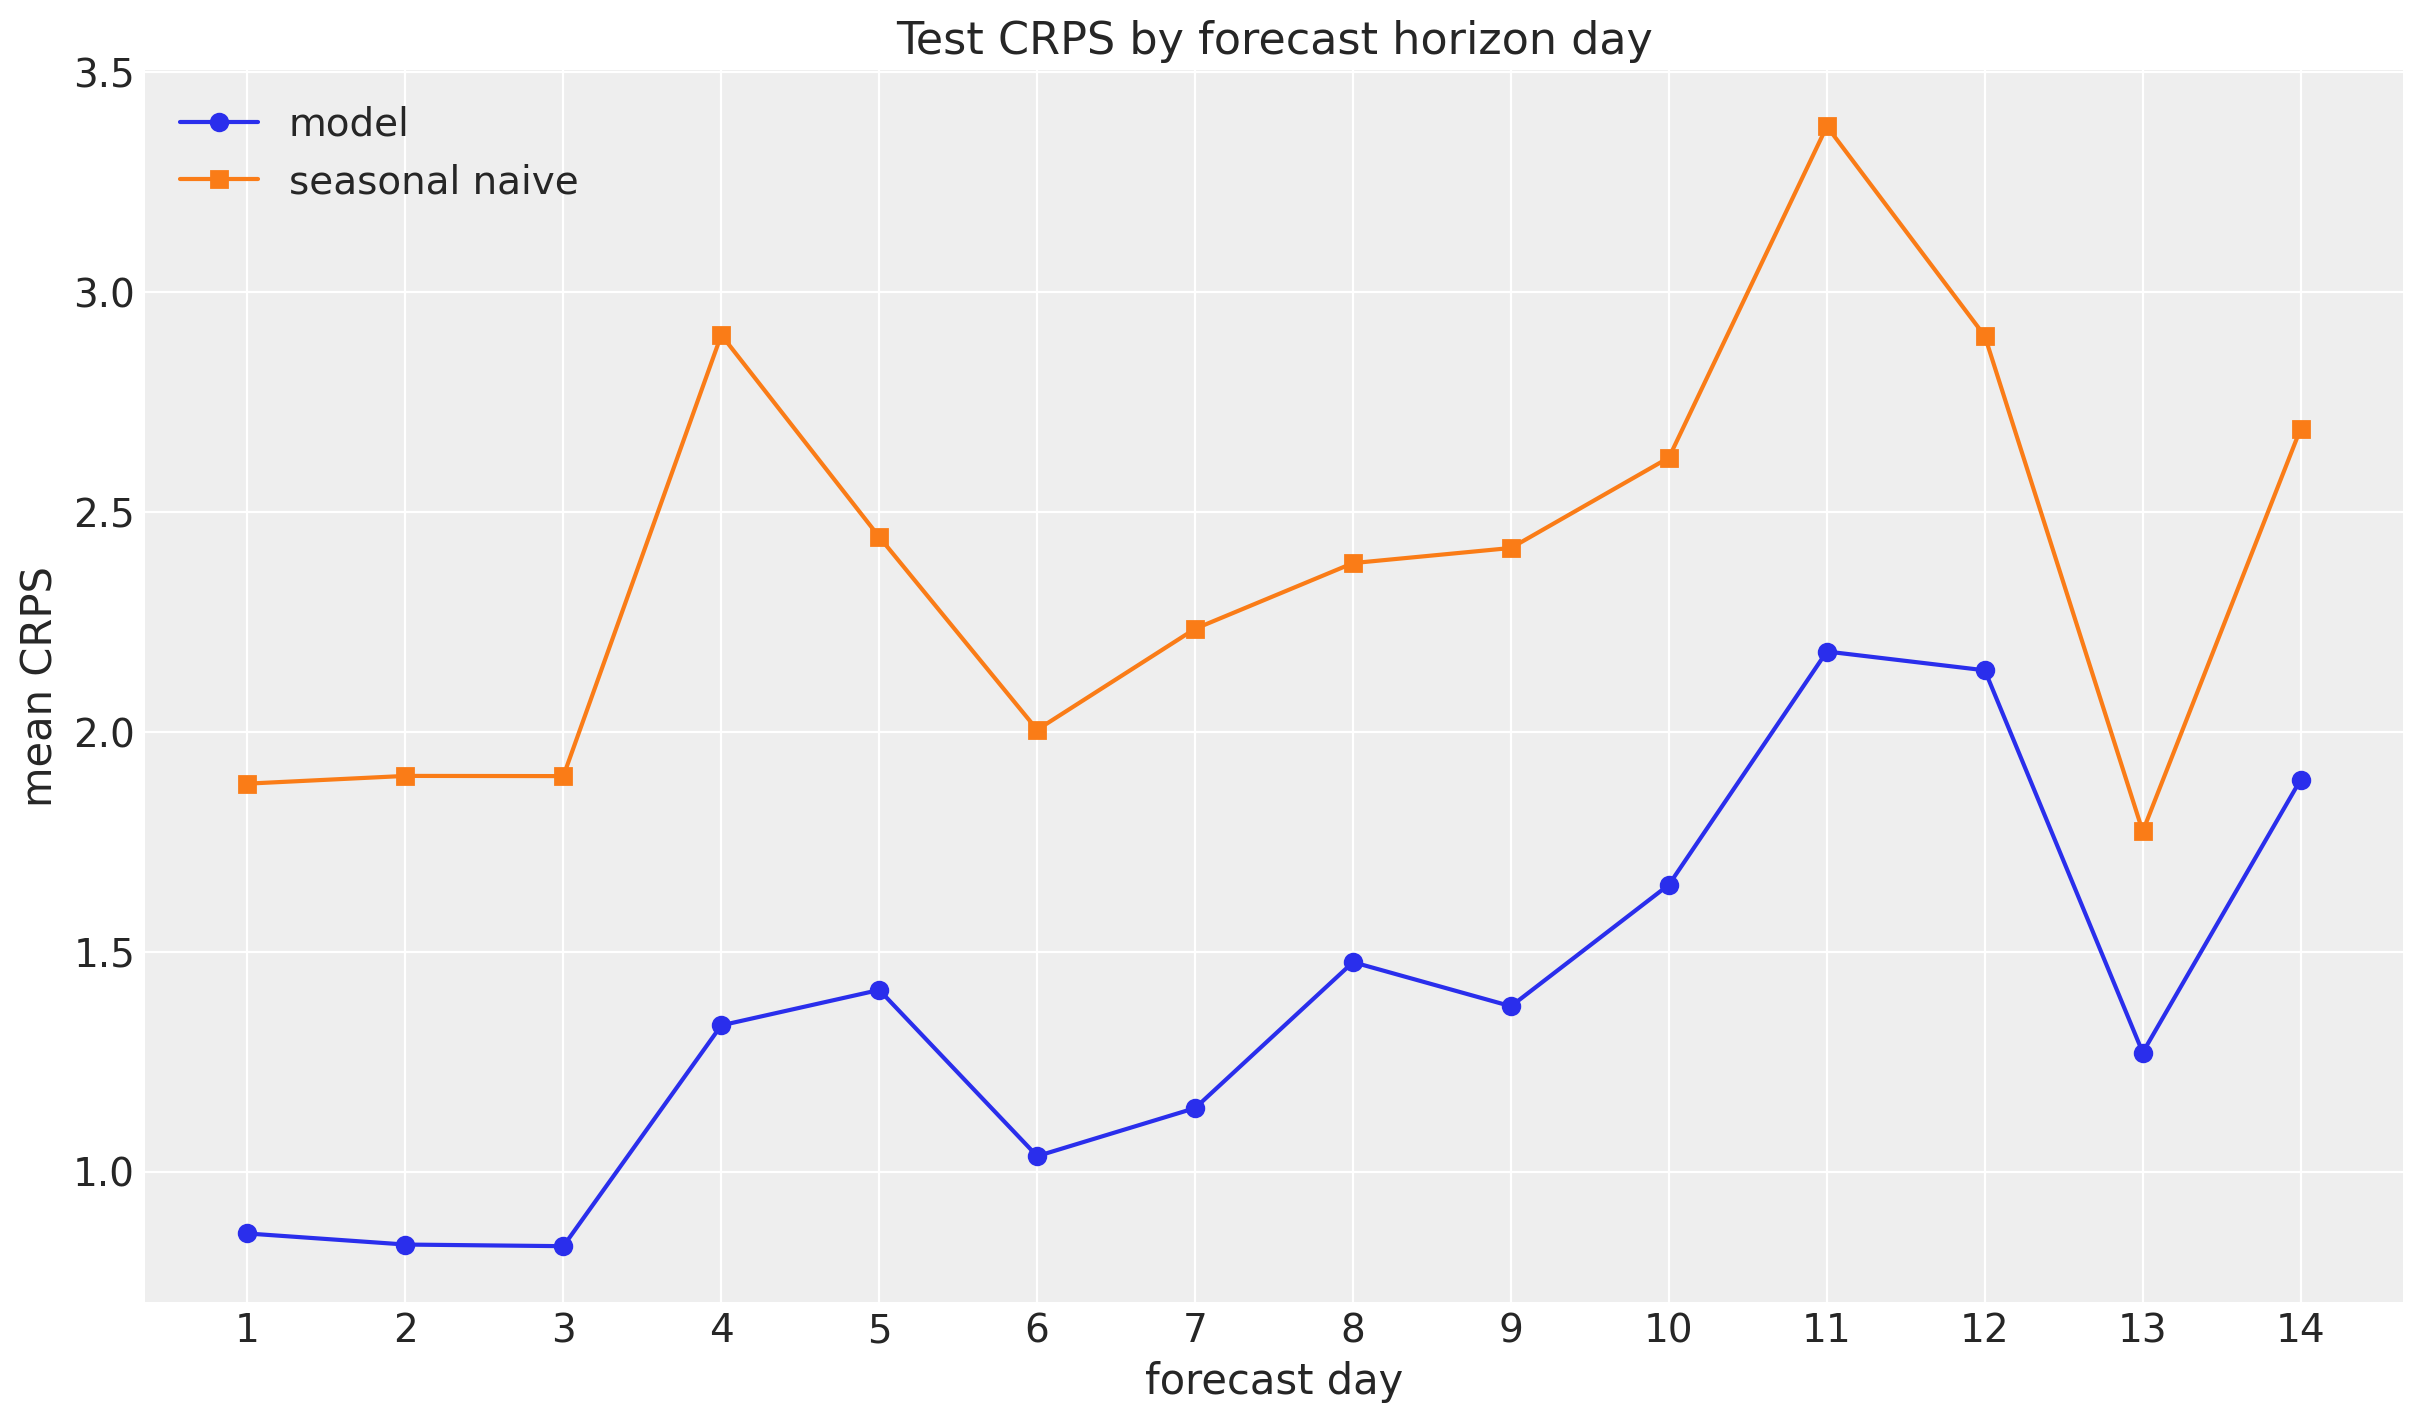

In [24]:
crps_by_day_model = np.asarray(crps_empirical(pred_test, y_test_original).mean(axis=-1))
crps_by_day_naive = np.asarray(crps_empirical(naive_test, y_test_original).mean(axis=-1))

fig, ax = plt.subplots()
ax.plot(np.arange(1, horizon + 1), crps_by_day_model, marker="o", color="C0", label="model")
ax.plot(
    np.arange(1, horizon + 1), crps_by_day_naive, marker="s", color="C1", label="seasonal naive"
)
ax.legend(loc="upper left")
ax.set(
    xlabel="forecast day",
    ylabel="mean CRPS",
    title="Test CRPS by forecast horizon day",
    xticks=np.arange(1, horizon + 1),
)

## Forecast visualization

The in-sample posterior predictive (blue) and the $14$-day forecast (orange) for the six focus series, with the $50\%$ and $94\%$ HDI bands, the observed sales in black, and availability in the background. Note how the bands collapse toward zero whenever availability drops, including in the forecast window: the factor propagates the known future availability into the predictive distribution.

Text(0.5, 1.02, 'FreshRetailNet forecasts (test CRPS 1.39 vs seasonal naive 2.39)')

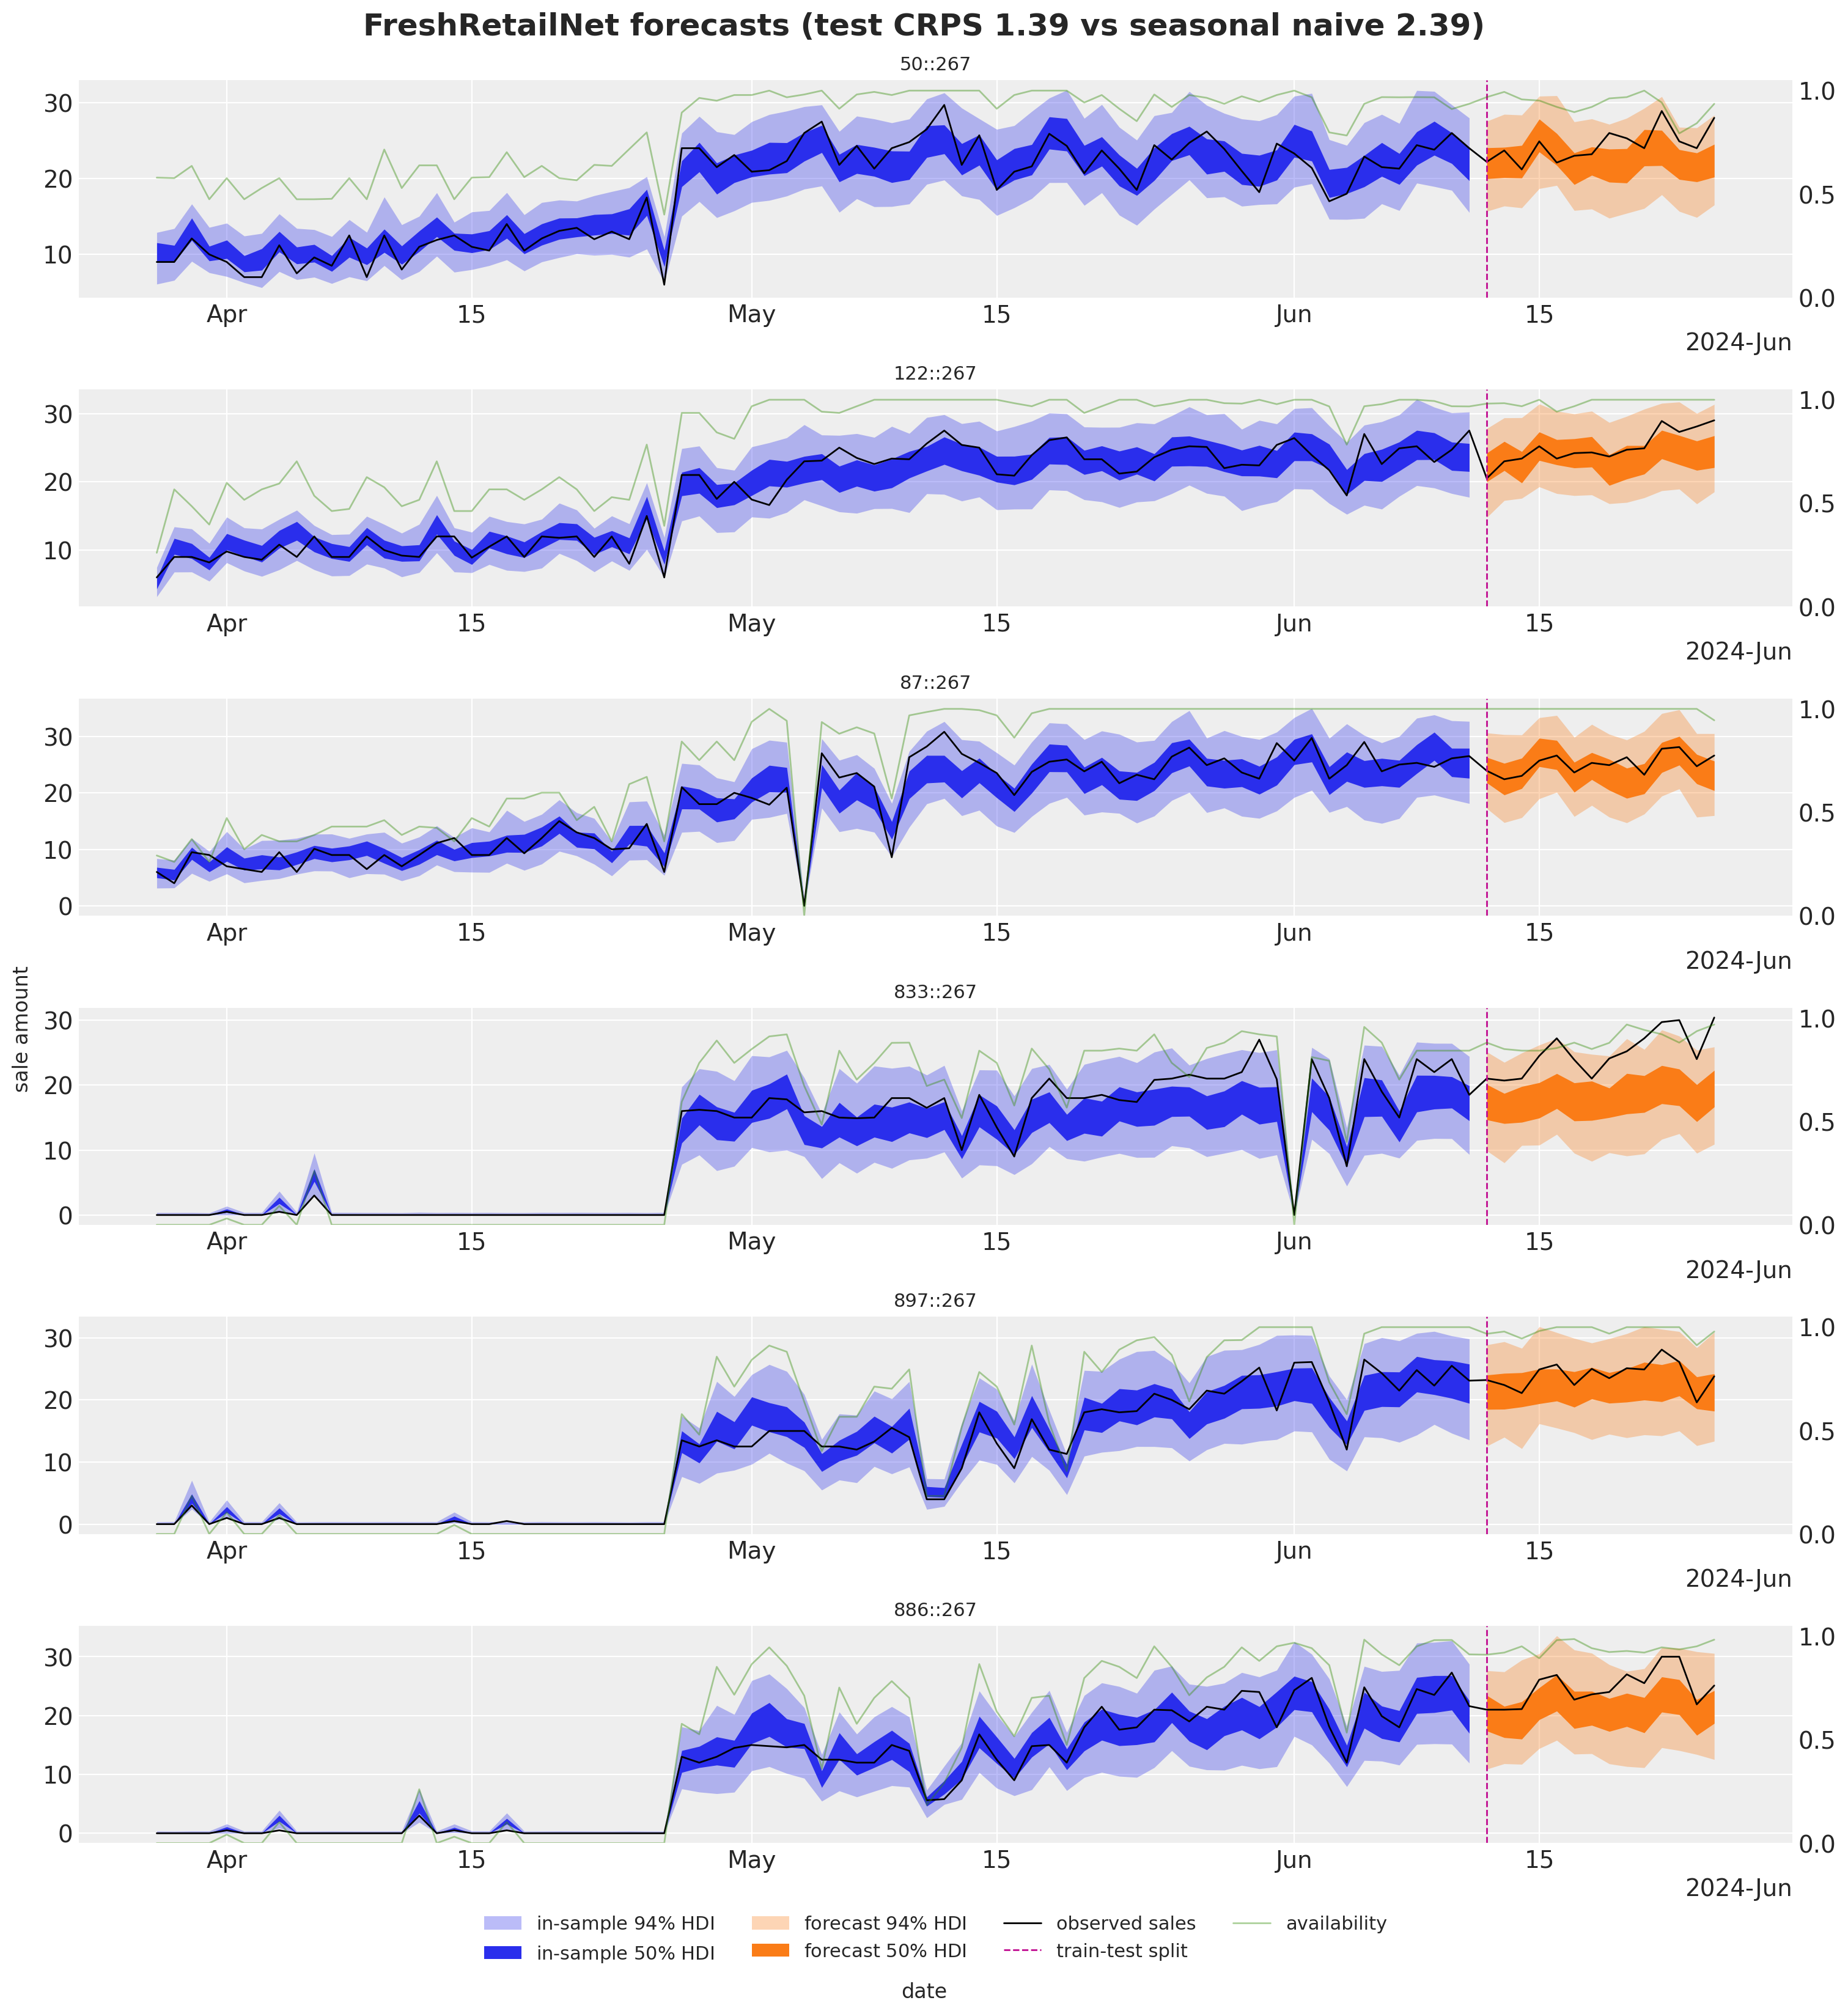

In [25]:
pc = az.plot_lm(
    faceted_idata(np.asarray(pred_train)[:, :, plot_idx], dates_num[:t_train], plot_labels),
    y="obs",
    x="t",
    plot_dim="time",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    col_wrap=1,
    visuals={
        "ci_band": {"color": "C0"},
        "observed_scatter": False,
        "pe_line": False,
        "xlabel": False,
        "ylabel": False,
    },
    figure_kwargs={"figsize": (15, 16)},
)
train_bands = pc.viz["ci_band"]["t"].sel(series=plot_labels[-1])
band_train_94 = train_bands.sel(prob=0.94).item()
band_train_50 = train_bands.sel(prob=0.5).item()
az.plot_lm(
    faceted_idata(np.asarray(pred_test)[:, :, plot_idx], dates_num[t_train:], plot_labels),
    y="obs",
    x="t",
    plot_dim="time",
    plot_collection=pc,
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={
        "ci_band": {"color": "C1"},
        "observed_scatter": False,
        "pe_line": False,
        "xlabel": False,
        "ylabel": False,
    },
)

truth_da = xr.DataArray(
    y_full[:, plot_idx],
    dims=["time", "series"],
    coords={"time": dates_num, "series": plot_labels},
    name="t",
)
x_da = xr.DataArray(dates_num, dims=["time"], coords={"time": dates_num})
pc.map(
    az.visuals.line_xy,
    "truth",
    data=truth_da,
    x=x_da,
    ignore_aes=pc.aes_set,
    color="black",
    lw=1,
)

for label, idx in zip(plot_labels, plot_idx, strict=True):
    ax = pc.get_target("t", {"series": label})
    ax.set_title(label, fontsize=11)
    split_line = ax.axvline(split_x, color="C3", linestyle="--", linewidth=1)
    ax_twin = ax.twinx()
    (availability_line,) = ax_twin.plot(
        dates_num, availability_full[:, idx], color="C2", alpha=0.4, linewidth=1
    )
    ax_twin.grid(False)
    ax_twin.set(ylim=(0, 1.05))
    locator = mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

test_bands = pc.viz["ci_band"]["t"].sel(series=plot_labels[-1])
band_test_94 = test_bands.sel(prob=0.94).item()
band_test_50 = test_bands.sel(prob=0.5).item()
band_train_94.set_label(r"in-sample $94\%$ HDI")
band_train_50.set_label(r"in-sample $50\%$ HDI")
band_test_94.set_label(r"forecast $94\%$ HDI")
band_test_50.set_label(r"forecast $50\%$ HDI")
truth_line = pc.viz["truth"]["t"].sel(series=plot_labels[-1]).item()
truth_line.set_label("observed sales")
split_line.set_label("train-test split")
availability_line.set_label("availability")

fig = pc.viz["figure"].item()
ax_last = pc.get_target("t", {"series": plot_labels[-1]})
ax_last.legend(
    handles=[
        band_train_94,
        band_train_50,
        band_test_94,
        band_test_50,
        truth_line,
        split_line,
        availability_line,
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncols=4,
    fontsize=11,
)
fig.supxlabel("date")
fig.supylabel("sale amount")
fig.suptitle(
    f"FreshRetailNet forecasts (test CRPS {crps_test_model:.2f} "
    f"vs seasonal naive {crps_test_naive:.2f})",
    fontsize=18,
    fontweight="bold",
    y=1.02,
)

## Inspecting the availability factor

The factor parameters are per series, so we can ask what the model actually learned about stockouts. First the floor $\phi_s$ and the saturation rate $b_s$ across the panel:

Text(0.5, 0.98, 'Posterior availability-factor parameters')

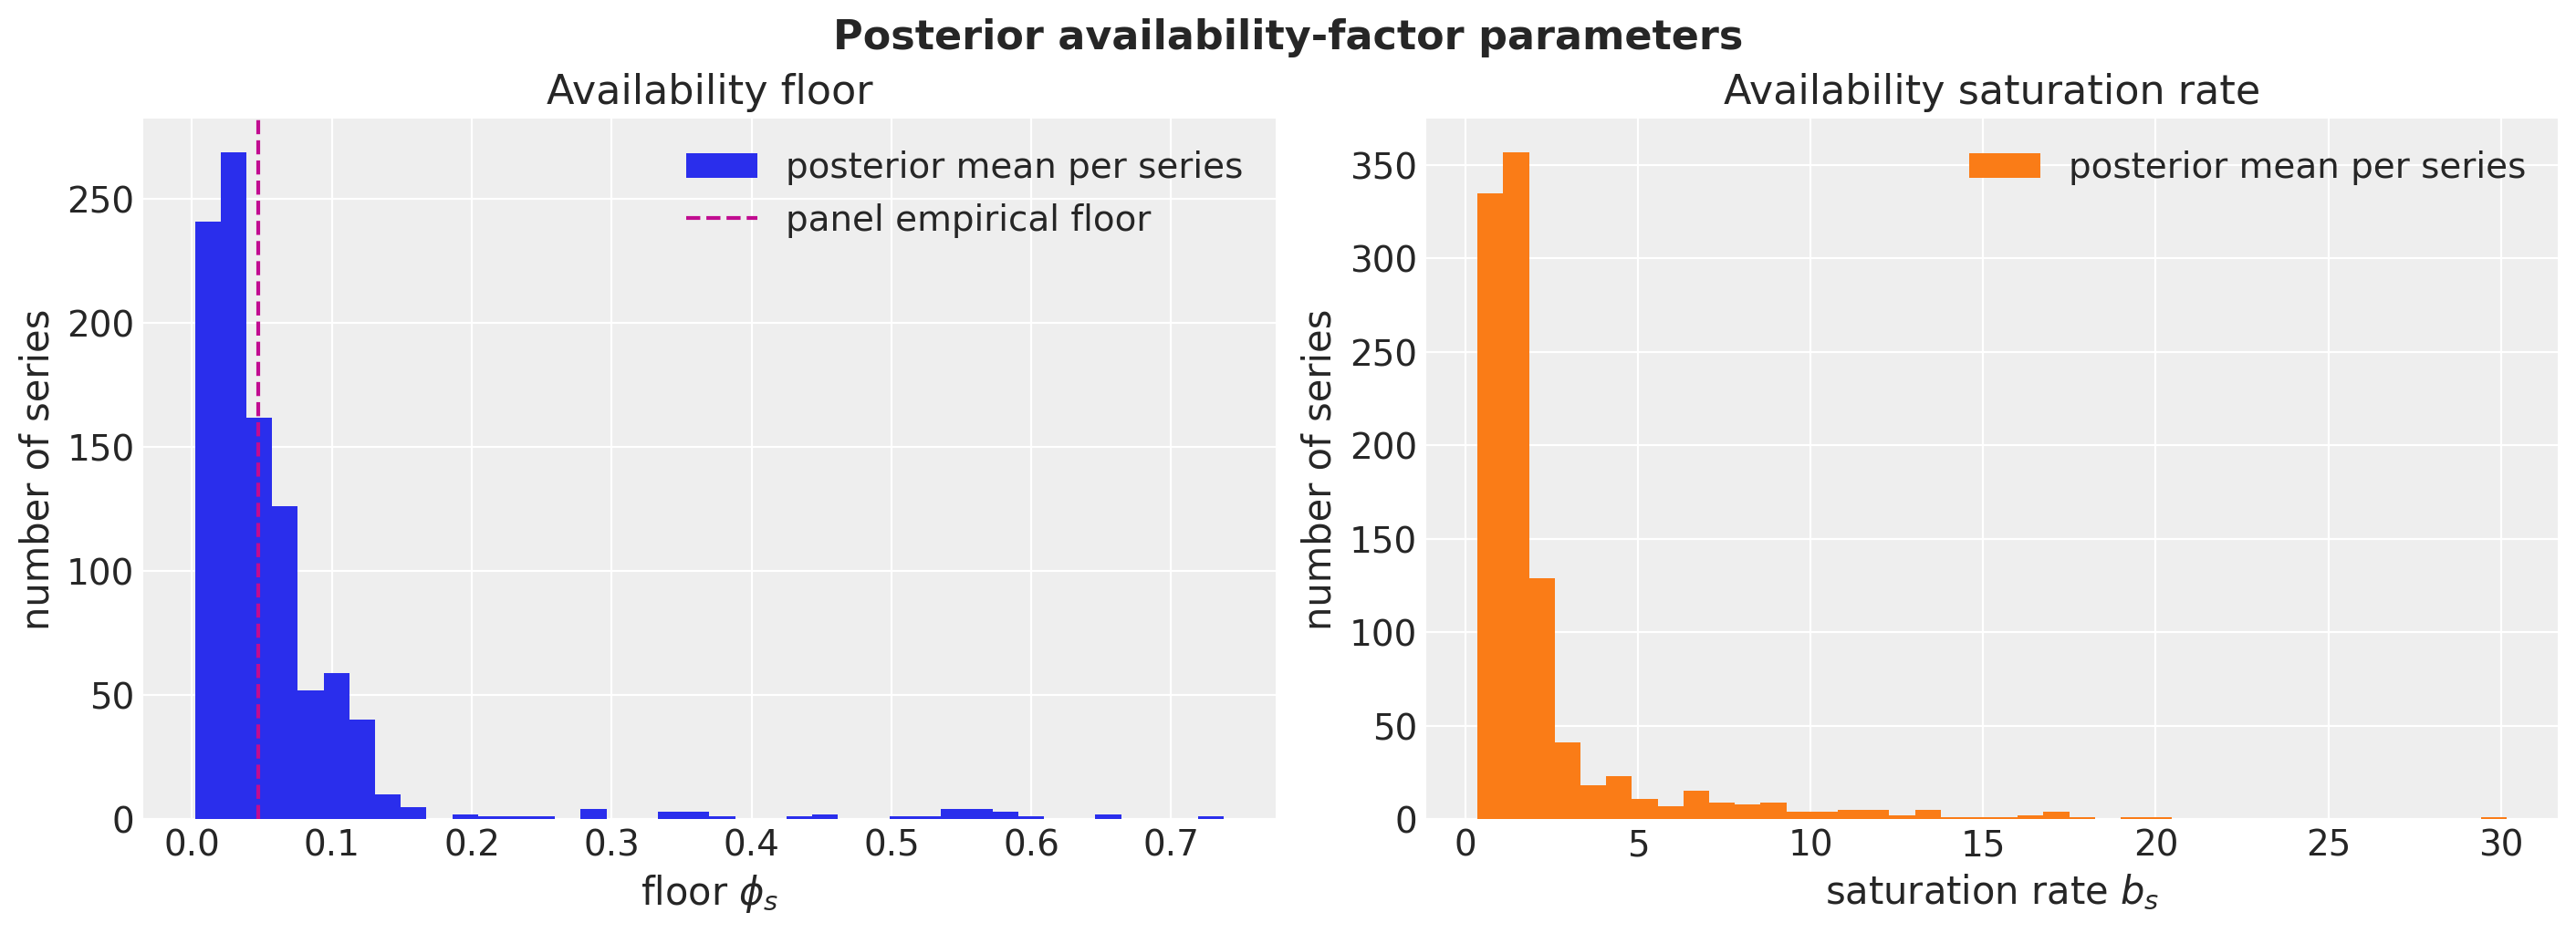

In [26]:
floor_mean = tree["posterior"]["floor"].mean(dim=("chain", "draw")).values
b_avail_mean = tree["posterior"]["b_avail"].mean(dim=("chain", "draw")).values

train_availability = availability_full[:t_train].ravel()
train_scaled_sales = y_scaled[:t_train].ravel()
panel_floor = float(train_scaled_sales[train_availability == 0.0].mean())

fig, axes = plt.subplots(ncols=2, figsize=(14, 5), layout="constrained")
axes[0].hist(np.asarray(floor_mean), bins=40, color="C0", label="posterior mean per series")
axes[0].axvline(panel_floor, color="C3", linestyle="--", label="panel empirical floor")
axes[0].legend(loc="upper right")
axes[0].set(xlabel=r"floor $\phi_s$", ylabel="number of series", title="Availability floor")
axes[1].hist(np.asarray(b_avail_mean), bins=40, color="C1", label="posterior mean per series")
axes[1].legend(loc="upper right")
axes[1].set(
    xlabel=r"saturation rate $b_s$",
    ylabel="number of series",
    title="Availability saturation rate",
)
fig.suptitle("Posterior availability-factor parameters", fontsize=16, fontweight="bold")

And the implied factor curve, averaged over series, against the panel's own empirical curve:

[Text(0.5, 0, 'sales-weighted availability'),
 Text(0, 0.5, 'availability factor'),
 Text(0.5, 1.0, 'Posterior availability factor (panel mean) vs empirical curve')]

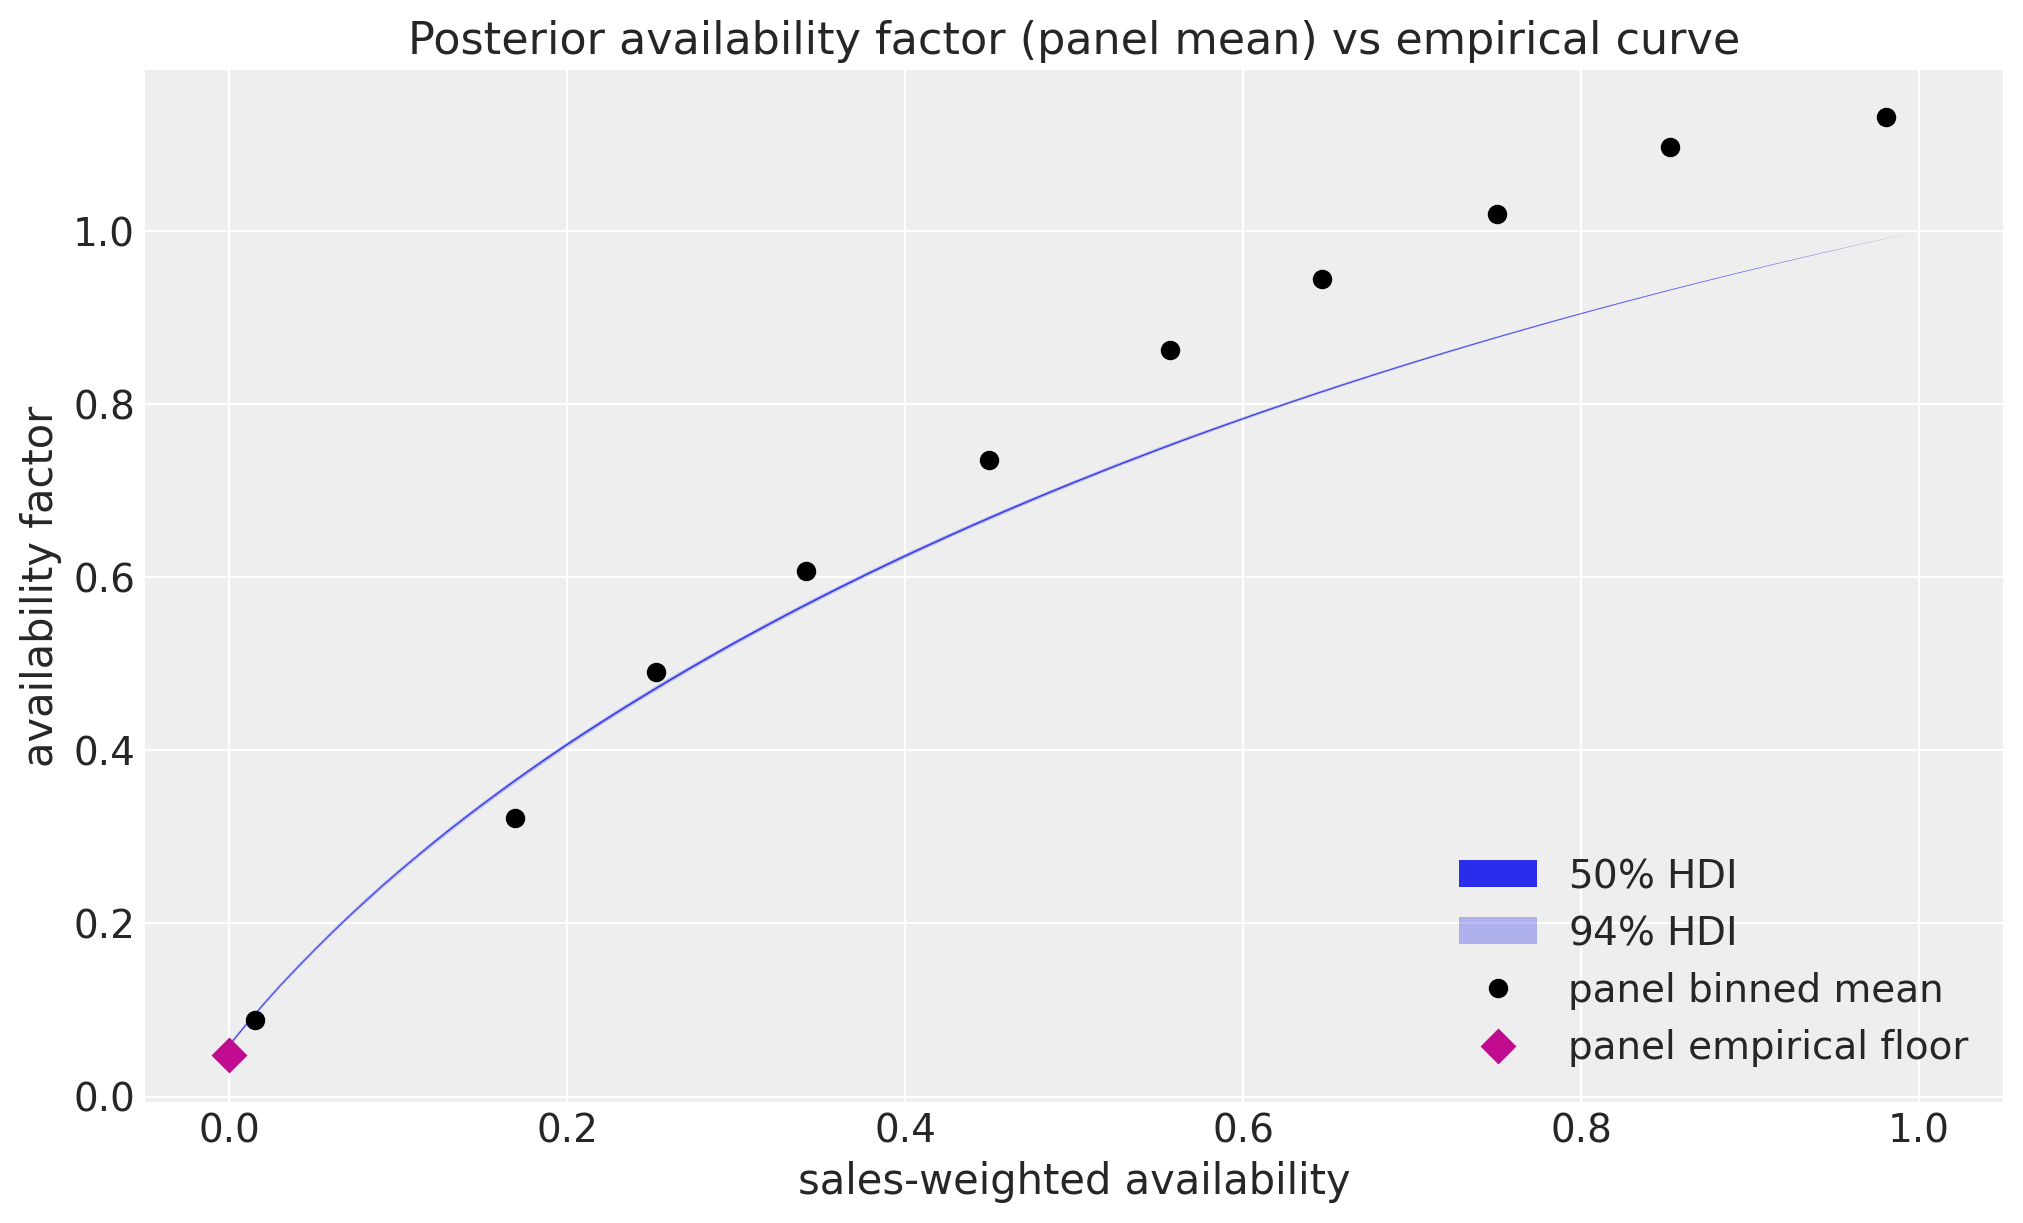

In [27]:
floor_draws = jnp.asarray(tree["posterior"]["floor"].values).reshape(-1, n_series)[:250]
b_draws = jnp.asarray(tree["posterior"]["b_avail"].values).reshape(-1, n_series)[:250]
saturation_draws = jnp.expm1(-b_draws[..., None] * grid_jax) / jnp.expm1(-b_draws[..., None])
factor_draws = floor_draws[..., None] + (1.0 - floor_draws[..., None]) * saturation_draws
factor_panel_curves = np.asarray(factor_draws.mean(axis=1))

availability_bins = np.clip((train_availability * 10).astype(np.int64), 0, 9)
panel_bin_availability = np.array(
    [train_availability[availability_bins == b].mean() for b in range(10)]
)
panel_bin_sales = np.array([train_scaled_sales[availability_bins == b].mean() for b in range(10)])

pc = az.plot_lm(
    faceted_idata(factor_panel_curves[:, :, None], availability_grid, ["posterior factor"]),
    y="obs",
    x="t",
    plot_dim="time",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={
        "ci_band": {"color": "C0"},
        "observed_scatter": False,
        "pe_line": False,
        "xlabel": False,
        "ylabel": False,
    },
    figure_kwargs={"figsize": (10, 6)},
)
ax = pc.get_target("t", {"series": "posterior factor"})
ax.plot(panel_bin_availability, panel_bin_sales, "o", color="black", label="panel binned mean")
ax.plot(0.0, panel_floor, "D", color="C3", markersize=8, label="panel empirical floor")
bands = pc.viz["ci_band"]["t"].sel(series="posterior factor")
band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
band_94.set_label(r"$94\%$ HDI")
band_50.set_label(r"$50\%$ HDI")
ax.legend(loc="lower right")
ax.set(
    xlabel="sales-weighted availability",
    ylabel="availability factor",
    title="Posterior availability factor (panel mean) vs empirical curve",
)

The posterior curve reproduces the saturating shape and the positive floor. It sits slightly below the raw binned points in the middle range, which is the endogeneity correction at work: part of the raw curve's height reflects that high-demand days sell out more often, and the model attributes that portion to the trend and seasonality instead of to availability itself.

## Inspecting the store hierarchy

The covariate effects are pooled by store. Plotting each series' discount effect against its store-level location shows the partial pooling: series means line up along the diagonal but are shrunk toward their store's location, more strongly for stores where the scale $\sigma^{\text{store}}$ is small.

[Text(0.5, 0, 'store-level posterior mean'),
 Text(0, 0.5, 'series-level posterior mean'),
 Text(0.5, 1.0, 'Discount effects shrink toward their store-level locations')]

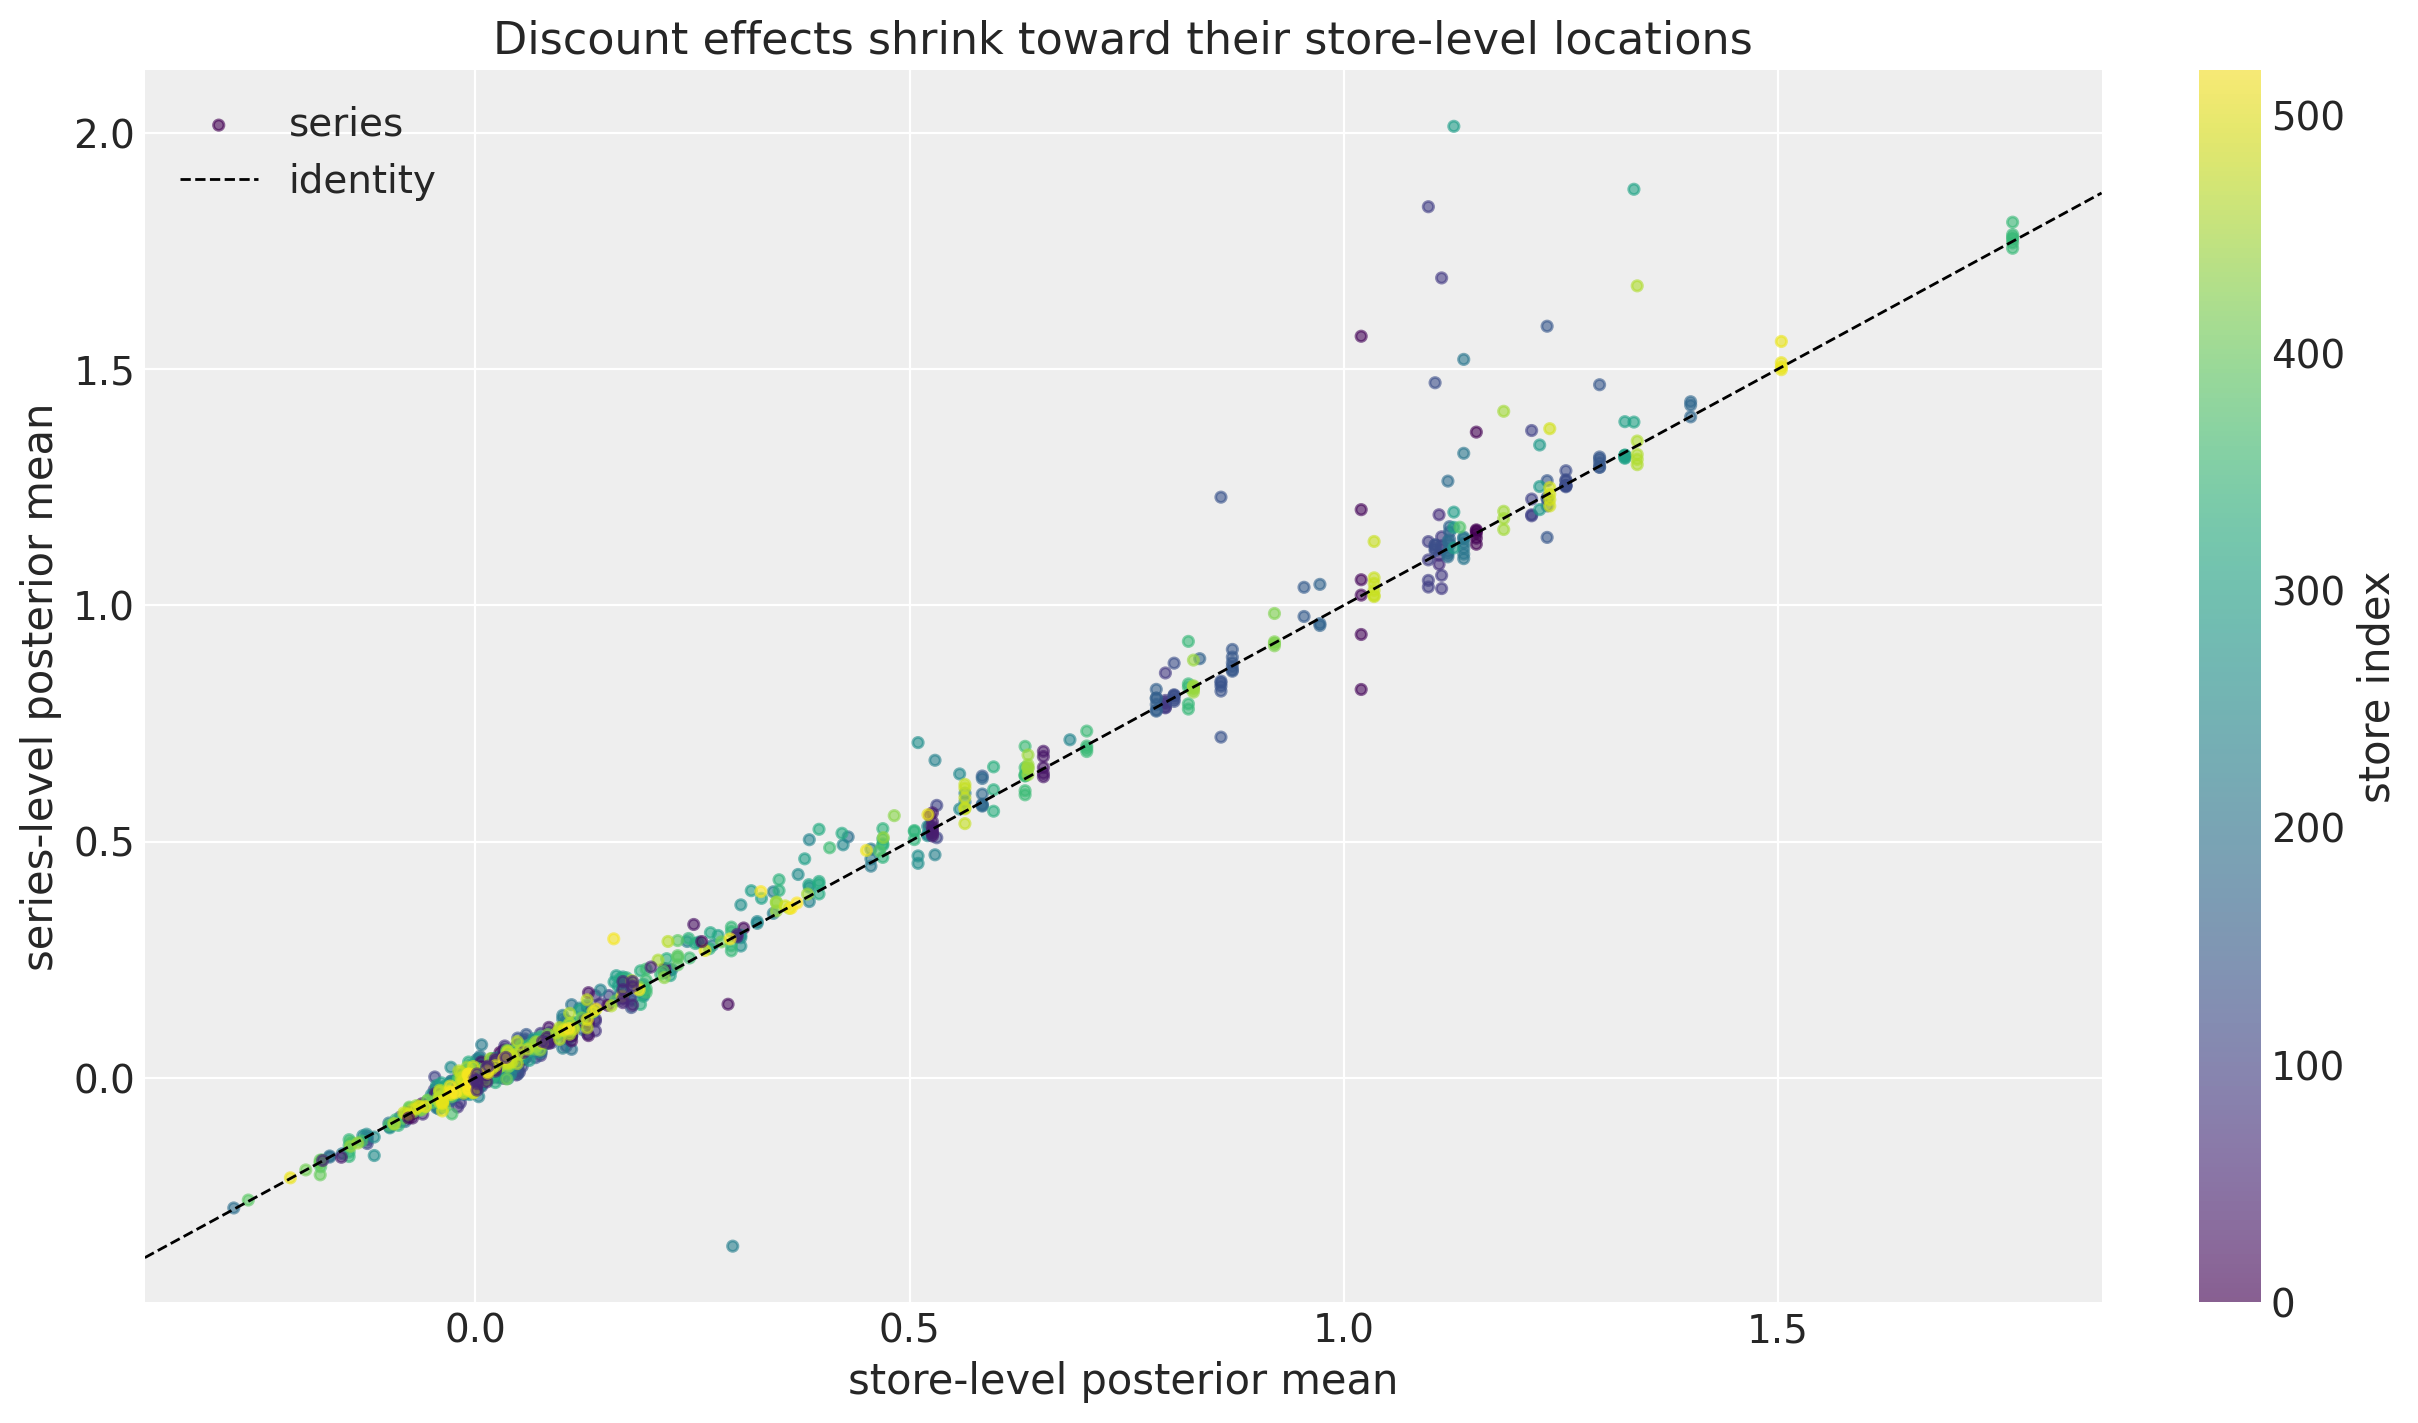

In [28]:
b_series_mean = (
    tree["posterior"]["b"].sel(covariate="discount_magnitude").mean(dim=("chain", "draw")).values
)
b_store_loc_mean = (
    tree["posterior"]["b_loc_store"]
    .sel(covariate="discount_magnitude")
    .mean(dim=("chain", "draw"))
    .values
)
store_of_series = np.asarray(series_to_store)

fig, ax = plt.subplots()
scatter = ax.scatter(
    np.asarray(b_store_loc_mean)[store_of_series],
    np.asarray(b_series_mean),
    c=store_of_series,
    cmap="viridis",
    alpha=0.6,
    s=14,
    label="series",
)
ax.axline((0.0, 0.0), slope=1.0, color="black", linestyle="--", linewidth=1, label="identity")
ax.legend(loc="upper left")
fig.colorbar(scatter, ax=ax, label="store index")
ax.set(
    xlabel="store-level posterior mean",
    ylabel="series-level posterior mean",
    title="Discount effects shrink toward their store-level locations",
)

## Next steps

- Calibrate the forecast intervals: the holdout coverage is below nominal, so scale the predictive spread with a conformal-style correction estimated on a held-out calibration window before the test period.
- Replace the mean-level factor with a censored likelihood: treat sales as latent demand right-censored by the available stock, which uses the same availability feature but models the mechanism instead of its average effect.
- Move to a strictly positive observation model (for example a negative binomial on rounded units) so the zero-sales days need no clipping.
- Add the weather covariates (precipitation, temperature) that this notebook left out.
- Evaluate with rolling-origin backtesting via the package's `backtest` helper instead of a single split.

## References

- Yang, T., et al. (2025). [*FreshRetailNet-50K: A Stockout-Annotated Censored Demand Dataset for Latent Demand Recovery and Forecasting in Fresh Retail*](https://arxiv.org/abs/2505.16319). Dataset on [Hugging Face](https://huggingface.co/datasets/Dingdong-Inc/FreshRetailNet-50K).
- Orduz, J. [*Hierarchical forecasting with NumPyro (part I)*](https://juanitorduz.github.io/numpyro_hierarchical_forecasting_1/).
- Pyro. [*Forecasting III: Hierarchical Models*](https://pyro.ai/examples/forecasting_iii.html).
- Related examples: [hierarchical forecasting I](hierarchical_forecasting_1.html), [inference methods comparison](inference_methods_comparison.html).